(05-29-opties-crashrisico)=

# Opties en crashrisico

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1976–2010, van Mertons sprongmodel tot Santa-Clara en Yan.

**Wat we al weten.** In [](#02-09-black-scholes) waren diepe puts duur en lag de VIX
gemiddeld vier volatiliteitspunten boven de latere volatiliteit; [](#04-21-volatiliteit)
maakte van de VIX de risiconeutrale verwachte variantie. [De vorige
lecture](#05-28-termijnstructuur-premies) vond ook in obligaties tijdvariërende premies.
De rampenmodellen uit [](#05-27-drie-antwoorden) laten een kleine kans op een grote crash
de equity premium dragen, maar een eeuw rendementen bevat te weinig crashes om dat te
toetsen.

**Welke vraag staat open.** Kunnen optieprijzen, die de markt elke dag opnieuw
vaststelt, meten hoeveel beleggers betalen om van crashrisico af te komen — en is die
prijs een risicopremie of een vergissing?
```

## Overzicht

Een putoptie op de index is een verzekering tegen een crash, en haar premie verraadt
hoe groot en hoe erg de markt de schade vindt. Dat maakt opties tot een meetinstrument
voor wat rendementsdata het slechtst meten: de staart. Pedro Santa-Clara en
Shu Yan schatten in *Crashes, Volatility, and the Equity Premium: Lessons from S&P 500
Options* {cite}`SantaClaraYan2010` een model met stochastische volatiliteit én een
stochastische crashintensiteit op de dagelijkse prijzen van S&P 500-opties, en haalden
er de equity premium uit die beleggers op elk moment eisen. Dit werk definieert het
tijdvak omdat het de equity premium puzzle uit [](#03-13-equity-premium-puzzle) omdraait:
niet het gerealiseerde gemiddelde met zijn standaardfout van twee procentpunt, maar
de prijs van risico zoals die elke dag in de optiemarkt wordt vastgesteld.

De tweede helft gaat over wie die verzekering verkoopt. Alessio Saretto en Santa-Clara
lieten in *Option Strategies: Good Deals and Margin Calls* {cite}`SarettoSantaClara2009`
zien dat puts verkopen op papier uitstekend renderen en in de praktijk gevaarlijk is:
margeverplichtingen dwingen de verkoper te sluiten precies wanneer de verzekering
uitbetaalt. Epistemisch is dit een lecture over een feit met concurrerende
theorieën (motief 3). Dat puts duur zijn, betwist niemand; of dat een beloning is voor
risico dat niet te diversifiëren valt, of een mispricing die blijft bestaan omdat de
arbitrageur geen kapitaal heeft, is de open vraag.

We beginnen met drie toestanden waarin een crash met twee procent kans een
risiconeutrale kans van vijftien procent krijgt. De theorie loopt van Breeden en
Litzenberger via de variance risk premium en Mertons sprongmodel naar Coval en Shumway en
de rekenkunde van marges. De simulatie vindt de risiconeutrale dichtheid terug uit
gesimuleerde prijzen en laat een verkoper van puts dertig jaar handelen. De replicatie
schat de risiconeutrale dichtheid van SPY, herhaalt de regressie van Bollerslev, Tauchen
en Zhou {cite}`BollerslevTauchenZhou2009`, en zet de Cboe PutWrite-index naast de S&P 500.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial
from scipy import optimize, special, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Op maandag 19 oktober 1987 verloor de S&P 500 ruim twintig procent op één dag. Bij een
dagvolatiliteit van ongeveer één procent is dat onder Black-Scholes een uitschieter van
twintig standaarddeviaties, met een kans die praktisch nul is. De optiemarkt trok haar
conclusie sneller dan de theorie: sinds die dag zijn puts ver onder de koers duur in
volatiliteitstermen, de *smirk* (een implied volatility die daalt naarmate de
uitoefenprijs stijgt) uit [](#fig-black-scholes-smirk). David Bates noemde het
verschijnsel in de titel van zijn artikel *post-'87 crash fears* {cite}`Bates2000`.

Waarom is crashangst wel in optieprijzen te zien en nauwelijks in rendementen? Een
optieprijs vat twee dingen samen: hoe waarschijnlijk een toestand is, en hoeveel een euro
dan waard is. In een crash is iedereen tegelijk armer, dus een euro die dan uitbetaalt is
veel waard, en de markt prijst een put alsof de crash veel waarschijnlijker is dan hij is. Die opgeblazen kans heet de *risiconeutrale* kans (de
kans waaronder elke belegging gemiddeld precies de rente oplevert), en het verschil met
de werkelijke kans is de prijs van crashrisico.

Daaruit volgen drie dingen. Wie alle optieprijzen kent, kent de risiconeutrale verdeling:
drie opties met naburige uitoefenprijzen betalen samen alleen uit als de koers precies
daar eindigt. Wie verzekering verkoopt, verdient meestal een beetje en verliest zelden
veel; zijn gemiddelde hangt aan gebeurtenissen die in twintig jaar één keer of nooit
voorkomen, en een steekproef zonder crash toont een Sharpe-ratio die niets met de
werkelijkheid te maken heeft (motief 1). En wie met geleend geld verkoopt, moet onderpand
bijstorten zodra de markt daalt, en wordt gedwongen te stoppen op het slechtste moment.

Een put verkopen is Santa-Clara's "bearing risk that was priced" {cite}`SantaClara2026`;
de Sharpe-ratio van een periode zonder crash voor informatie aanzien is "thinking I knew
something the price did not". De optieprijs wist van de crash, de steekproef niet.

## Toy-voorbeeld: normaal op, normaal neer, crash

Een Lucas-boom als in [](#03-12-consumptie-capm), met drie toestanden op $t+1$. De
markt levert een bruto rendement gelijk aan de consumptiegroei $g$: $1{,}10$ als het
goed gaat (kans $0{,}65$), $0{,}95$ in een gewone tegenvaller (kans $0{,}33$) en
$0{,}60$ in een crash (kans $0{,}02$, eens in de vijftig jaar). De representatieve
belegger heeft CRRA-nut met $\gamma = 4$ en $\beta = 0{,}97$.

**De SDF.** De *stochastic discount factor* (SDF: de toestandsafhankelijke factor waarmee
payoffs worden verdisconteerd) is $m = \beta g^{-\gamma}$ per toestand:

$$
m_{\text{op}} = \frac{0{,}97}{1{,}10^4} = \frac{0{,}97}{1{,}4641} = 0{,}6625, \quad
m_{\text{neer}} = \frac{0{,}97}{0{,}8145} = 1{,}1909, \quad
m_{\text{crash}} = \frac{0{,}97}{0{,}1296} = 7{,}4846 .
$$

Dan is $\E[m] = 0{,}65 \cdot 0{,}6625 + 0{,}33 \cdot 1{,}1909 + 0{,}02 \cdot 7{,}4846
= 0{,}4306 + 0{,}3930 + 0{,}1497 = 0{,}9733$ en $R^{f} = 1/\E[m] = 1{,}0274$.

**De risiconeutrale kansen.** $q_s = p_s m_s/\E[m]$, zodat $\sum_s q_s = 1$ en elke
prijs gelijk is aan $\E^{\mathbb Q}[x]/R^{f}$:

| toestand | $g$ | $p$ | $m$ | $q$ | $q/p$ |
|---|---|---|---|---|---|
| op | $1{,}10$ | $0{,}65$ | $0{,}6625$ | $0{,}4424$ | $0{,}68$ |
| neer | $0{,}95$ | $0{,}33$ | $1{,}1909$ | $0{,}4038$ | $1{,}22$ |
| crash | $0{,}60$ | $0{,}02$ | $7{,}4846$ | $0{,}1538$ | $7{,}69$ |

De crash, die twee procent van de tijd voorkomt, krijgt vijftien procent van de
risiconeutrale kansmassa.

**De markt.** De prijs is $\E[mg] = 0{,}65 \cdot 0{,}7288 + 0{,}33 \cdot 1{,}1314 +
0{,}02 \cdot 4{,}4908 = 0{,}9369$, het verwachte rendement $1{,}0405/0{,}9369 = 1{,}1106$,
en de equity premium $8{,}32\%$. Zonder crashtoestand (de andere kansen herschaald) is ze
$2{,}44\%$.

**Een put.** Een put met uitoefenprijs $0{,}90$ betaalt alleen in de crash, $0{,}30$. Zijn
prijs is $0{,}02 \cdot 7{,}4846 \cdot 0{,}30 = 0{,}0449$, zijn verwachte payoff
$0{,}02 \cdot 0{,}30 = 0{,}0060$, en zijn verwachte bruto rendement $0{,}0060/0{,}0449 =
0{,}1336$: een verwacht verlies van $86{,}6\%$ per periode. Een at-the-money-put
($K = 1$) kost $0{,}33 \cdot 1{,}1909 \cdot 0{,}05 + 0{,}02 \cdot 7{,}4846 \cdot 0{,}40 =
0{,}0795$ en verwacht $0{,}0245$ terug ($-69\%$); driekwart van zijn prijs komt uit de
crash. Een call met $K = 1{,}05$ kost $0{,}65 \cdot 0{,}6625 \cdot 0{,}05 = 0{,}0215$ en
verwacht $0{,}0325$ terug: $+50{,}9\%$, ruim boven de markt, de ordening van
[](#thm-opties-crashrisico-cs).

**De variance risk premium.** Neem als gerealiseerde variantie $(\log g)^2$: $0{,}0091$,
$0{,}0026$ en $0{,}2609$. Onder $p$ is de verwachting $0{,}0120$ (een volatiliteit van
$11{,}0\%$), onder $q$ is ze $0{,}4424 \cdot 0{,}0091 + 0{,}4038 \cdot 0{,}0026 + 0{,}1538 \cdot
0{,}2609 = 0{,}0452$ ($21{,}3\%$). Het verschil, $0{,}0332$, komt bijna geheel uit de
crashtoestand.

In [2]:
beta_toy, gamma_toy = 0.97, 4.0
states = ["op", "neer", "crash"]
growth = np.array([1.10, 0.95, 0.60])          # gross market return = consumption growth
prob = np.array([0.65, 0.33, 0.02])            # physical probabilities

m_toy = beta_toy * growth ** (-gamma_toy)      # SDF per state
Em = prob @ m_toy
Rf_toy = 1 / Em
q_toy = prob * m_toy / Em                      # risk-neutral probabilities

payoffs = {
    "markt": growth,
    "put K = 0,90": np.maximum(0.90 - growth, 0.0),
    "put K = 1,00": np.maximum(1.00 - growth, 0.0),
    "call K = 1,05": np.maximum(growth - 1.05, 0.0),
}
rows = {}
for name, x in payoffs.items():
    price = prob @ (m_toy * x)
    rows[name] = {"prijs": price, "prijs via Q": (q_toy @ x) / Rf_toy,
                  "E[x]": prob @ x, "E[R]": (prob @ x) / price}
assets_toy = pd.DataFrame(rows).T

rv_toy = np.log(growth) ** 2
vrp_toy = q_toy @ rv_toy - prob @ rv_toy

p_nc, m_nc, g_nc = prob[:2] / prob[:2].sum(), m_toy[:2], growth[:2]   # same economy without the crash
premium_nc = (p_nc @ g_nc) / (p_nc @ (m_nc * g_nc)) - 1 / (p_nc @ m_nc)

assert np.allclose(m_toy, [0.6625, 1.1909, 7.4846], atol=5e-5)
assert np.allclose(q_toy, [0.4424, 0.4038, 0.1538], atol=5e-5)
assert np.isclose(assets_toy.loc["put K = 0,90", "prijs"], 0.0449, atol=5e-5)
print(pd.DataFrame({"groei": growth, "p": prob, "m": m_toy, "q": q_toy, "q/p": q_toy / prob,
                    "(log groei)^2": rv_toy}, index=states).round(4))
print(f"E[m] = {Em:.4f}, R_f = {Rf_toy:.4f}, equity premium = {assets_toy.loc['markt', 'E[R]'] - Rf_toy:.4f}")
print(f"E^P[RV] = {prob @ rv_toy:.5f}, E^Q[RV] = {q_toy @ rv_toy:.5f}, VRP = {vrp_toy:.5f}")
print(f"equity premium zonder crashtoestand = {premium_nc:.4f}")
assets_toy.round(4)

       groei     p       m       q     q/p  (log groei)^2
op      1.10  0.65  0.6625  0.4424  0.6807         0.0091
neer    0.95  0.33  1.1909  0.4038  1.2235         0.0026
crash   0.60  0.02  7.4846  0.1538  7.6896         0.2609
E[m] = 0.9733, R_f = 1.0274, equity premium = 0.0832
E^P[RV] = 0.01199, E^Q[RV] = 0.04521, VRP = 0.03322
equity premium zonder crashtoestand = 0.0244


,prijs,prijs via Q,E[x],E[R]
markt,0.9369,0.9369,1.0405,1.1106
"put K = 0,90",0.0449,0.0449,0.0060,0.1336
"put K = 1,00",0.0795,0.0795,0.0245,0.3081
"call K = 1,05",0.0215,0.0215,0.0325,1.5094


De code reproduceert elke handberekening tot op vier decimalen; de kolom "prijs via Q"
bevestigt dat waarderen met $m$ onder $p$ en met de rente onder $q$ samenvallen.

## Theorie

### Opzet en notatie

Zoals in [](#02-09-black-scholes) heet de indexprijs $S_t$, en zijn $C_t(K,T)$ en
$P_t(K,T)$ de prijzen van Europese calls en puts met uitoefenprijs $K$ en expiratie $T$;
$\tau = T - t$. De rente $r$ is continu samengesteld en constant, $F_t = S_t
e^{(r-\delta)\tau}$ is de termijnkoers bij dividendrendement $\delta$. $\mathbb P$ is de
werkelijke kansmaat, $\mathbb Q$ de risiconeutrale, en $m_T$ de SDF tussen $t$ en $T$,
met $\E^{\mathbb Q}_t[X] = \E_t[m_T X]/\E_t[m_T]$ en $\E_t[m_T] = e^{-r\tau}$. De
risiconeutrale dichtheid van $S_T$ heet $q(s)$, de werkelijke $p(s)$.

### Breeden-Litzenberger: de verdeling zit in de kromming

*Waarom zou dit waar zijn?* Koop een call met uitoefenprijs $K - h$, verkoop er twee met
$K$ en koop er één met $K + h$. Deze *butterfly* (een driehoekige payoff rond $K$)
betaalt, gedeeld door $h^2$, één eenheid als de koers bij $K$ eindigt: een
Arrow-Debreu-effect uit [](#03-11-apt-no-arbitrage), en zijn prijs is een verdisconteerde
dichtheid {cite}`BreedenLitzenberger1978`.

:::{prf:theorem} Breeden-Litzenberger
:label: thm-opties-crashrisico-bl

Laat $S_T$ onder $\mathbb Q$ een continue dichtheid $q$ hebben, en laat
$C_t(K) = e^{-r\tau}\E^{\mathbb Q}_t[(S_T - K)^{+}]$ voor alle $K > 0$. Dan geldt

```{math}
:label: eq-opties-crashrisico-bl
\frac{\partial C_t}{\partial K} = -e^{-r\tau}\,\mathbb Q_t(S_T > K),
\qquad
\frac{\partial^2 C_t}{\partial K^2} = e^{-r\tau}\, q(K).
```

Voor puts geldt $\partial^2 P_t/\partial K^2 = e^{-r\tau} q(K)$ eveneens.
:::

:::{prf:proof}
Schrijf $C_t(K) = e^{-r\tau}\int_K^\infty (s - K)\, q(s)\,\mathrm ds$. De integrand is
nul in $s = K$, dus de regel van Leibniz geeft
$\partial C_t/\partial K = -e^{-r\tau}\int_K^\infty q(s)\,\mathrm ds$, en nog eens
differentiëren geeft $e^{-r\tau} q(K)$ omdat $q$ continu is. Put-call-pariteit
$C_t - P_t = e^{-r\tau}(F_t - K)$ is lineair in $K$, dus de tweede afgeleiden zijn gelijk.
$\square$
:::

Twee opmerkingen maken de stelling bruikbaar. Eén: de stelling geeft $q$, niet $p$.
Delen geeft de SDF als functie van de index,
$\E_t[m_T \mid S_T = s] = e^{-r\tau}\, q(s)/p(s)$, zoals $q/p$ in het toy-voorbeeld.
Jens Jackwerth schatte $q$ uit S&P 500-opties en $p$ uit historische rendementen over
2 april 1986 tot 29 december 1995, en rekende de impliciete risicoaversie uit
{cite}`Jackwerth2000`: "Precrash, they are positive and decreasing in wealth and largely
consistent with standard assumptions made in economic theory. Postcrash, they are
partially negative and partially increasing and irreconcilable with those assumptions.
Mispricing in the option market is the most likely cause." Een SDF die ergens *stijgt*
in de index heet sindsdien de *pricing kernel puzzle*. Twee: een tweede afgeleide
versterkt ruis; een prijsfout $\varepsilon$ wordt een dichtheidsfout van orde $\varepsilon/h^2$.

### Modelvrije momenten

*Waarom zou dit waar zijn?* Als elke butterfly een toestand is, dan is elke payoff die
alleen van $S_T$ afhangt een portefeuille van butterflies, en dus van opties. De
verwachting van $(\log S_T/F)^n$ onder $\mathbb Q$ is dan een prijs, en een prijs lees je
af.

:::{prf:proposition} Spanning en risiconeutrale momenten
:label: prop-opties-crashrisico-momenten

Voor elke twee keer differentieerbare $H$ geldt, met $F = F_t$ en $Q(K)$ de
out-of-the-money-optie ($P_t(K)$ voor $K < F$, $C_t(K)$ voor $K \geq F$),

```{math}
:label: eq-opties-crashrisico-spanning
e^{-r\tau}\E^{\mathbb Q}_t[H(S_T)] = e^{-r\tau}H(F) + \int_0^\infty H''(K)\, Q(K)\,\mathrm dK .
```

Met $R = \log(S_T/F)$ volgt
$\E^{\mathbb Q}_t[R] = -e^{r\tau}\int_0^\infty Q(K)K^{-2}\,\mathrm dK$,
$\E^{\mathbb Q}_t[R^2] = e^{r\tau}\int_0^\infty 2\bigl(1 - \log\tfrac KF\bigr)K^{-2}Q(K)\,\mathrm dK$ en
$\E^{\mathbb Q}_t[R^3] = e^{r\tau}\int_0^\infty \bigl(6\log\tfrac KF - 3\log^2\tfrac KF\bigr)K^{-2}Q(K)\,\mathrm dK$.
:::

:::{prf:proof}
Taylor met integraalrestterm rond $F$ geeft voor elke $s > 0$:
$H(s) = H(F) + H'(F)(s - F) + \int_0^F H''(K)(K - s)^{+}\mathrm dK + \int_F^\infty H''(K)(s - K)^{+}\mathrm dK$
(controleer voor $s > F$: de eerste integraal is nul en de tweede is
$\int_F^s H''(K)(s-K)\,\mathrm dK = H(s) - H(F) - H'(F)(s-F)$ na partiële integratie).
Neem $e^{-r\tau}\E^{\mathbb Q}_t$ en gebruik $\E^{\mathbb Q}_t[S_T - F] = 0$. Voor
$H = \log(s/F)$, $\log^2(s/F)$ en $\log^3(s/F)$ zijn $H(F) = 0$ en de tweede afgeleiden
$-1/s^2$, $2(1 - \log\frac sF)/s^2$ en $(6\log\frac sF - 3\log^2\frac sF)/s^2$. $\square$
:::

De eerste regel is de VIX-formule uit [](#thm-volatiliteit-vix); de andere twee geven
variantie en scheefheid, zoals Bakshi, Kapadia en Madan ze schreven. Zij vonden dat "individual
risk-neutral distributions differ from that of the market index by being far less
negatively skewed" {cite}`BakshiKapadiaMadan2003`: de linkerstaart is een eigenschap
van de *markt*, van het risico dat niet weg te diversifiëren valt, en niet van aandelen
in het algemeen.

### De variance risk premium

*Waarom zou dit waar zijn?* Een *variance swap* (een termijncontract dat op $T$ de
gerealiseerde variantie min een vooraf vastgestelde prijs uitbetaalt) kost niets om aan
te gaan, dus die vaste prijs is de risiconeutrale verwachting van de variantie. Of die
boven de werkelijke ligt, hangt af van *wanneer* de variantie hoog is: is een euro dan veel
waard, dan betaalt de koper graag te veel.

Laat $\mathrm{RV}_{t,T}$ de gerealiseerde variantie over $[t, T]$ zijn. We definiëren

```{math}
:label: eq-opties-crashrisico-vrp
\mathrm{VRP}_t \equiv \E^{\mathbb Q}_t\!\left[\mathrm{RV}_{t,T}\right] - \E_t\!\left[\mathrm{RV}_{t,T}\right].
```

Carr en Wu gebruiken [](#eq-opties-crashrisico-vrp) met het omgekeerde teken: de verwachte opbrengst
van een gekochte variance swap, $\E_t[\mathrm{RV}] - \E^{\mathbb Q}_t[\mathrm{RV}]$
{cite}`CarrWu2009`. Wij volgen Bollerslev, Tauchen en Zhou en de replicatie in
[](#02-09-black-scholes), zodat het getal positief is als opties duur zijn.

:::{prf:proposition} Het teken van de variance risk premium
:label: prop-opties-crashrisico-vrp

Voor elke payoff $X$ met eindige verwachting geldt
$\E^{\mathbb Q}_t[X] - \E_t[X] = \Cov_t(m_T, X)/\E_t[m_T]$. In het bijzonder is
$\mathrm{VRP}_t > 0$ dan en slechts dan als $\Cov_t(m_T, \mathrm{RV}_{t,T}) > 0$.
:::

:::{prf:proof}
$\E^{\mathbb Q}_t[X] = \E_t[m_T X]/\E_t[m_T] = \bigl(\E_t[m_T]\E_t[X] + \Cov_t(m_T,X)\bigr)/\E_t[m_T]$.
$\square$
:::

De SDF is hoog als de markt daalt, en de variantie ook: het *leverage effect* (volatiliteit
stijgt na dalingen) uit [](#04-21-volatiliteit). Samen geven ze $\Cov(m, \mathrm{RV}) > 0$
en een positieve premie; in het toy-voorbeeld $0{,}0332$, vrijwel geheel uit de
crashtoestand. Het niveau is gemeten in [](#fig-black-scholes-vrp). Bollerslev, Tauchen en
Zhou voegden toe dat een tijdvariërende prijs van risico een voorspeller moet zijn: de
premie "is able to explain a nontrivial fraction of the time-series variation in post-1990
aggregate stock market returns, with high (low) premia predicting high (low) future
returns" {cite}`BollerslevTauchenZhou2009`.

### Sprongen: het model van Merton

*Waarom zou dit waar zijn?* In [](#02-09-black-scholes) was de delta-hedge risicovrij
omdat de koers continu beweegt. Een sprong laat geen tijd om bij te stellen: de markt is
niet compleet, de optieprijs hangt af van hoe beleggers sprongrisico prijzen, en omdat een
sprong vooral de staart raakt, raakt hij vooral diepe puts.

Merton schreef in 1976 onder $\mathbb Q$

```{math}
:label: eq-opties-crashrisico-merton-sde
\frac{\mathrm dS_t}{S_{t-}} = (r - \delta - \lambda\kappa)\,\mathrm dt + \sigma\,\mathrm dW_t + (J - 1)\,\mathrm dN_t,
\qquad \log J \sim \mathcal N(\mu_J, \delta_J^2),
```

met $N$ een Poisson-proces met intensiteit $\lambda$ en $\kappa = \E[J - 1] =
e^{\mu_J + \delta_J^2/2} - 1$; de term $-\lambda\kappa$ compenseert de verwachte sprong, zodat
de index onder $\mathbb Q$ nog steeds de rente verdient {cite}`Merton1976`.
We zetten hieronder $\delta = 0$.

:::{prf:theorem} Mertons prijsformule
:label: thm-opties-crashrisico-merton

Onder [](#eq-opties-crashrisico-merton-sde) met $\delta = 0$ is

```{math}
:label: eq-opties-crashrisico-merton
C_t = \sum_{n=0}^{\infty} \frac{e^{-\lambda'\tau}(\lambda'\tau)^n}{n!}\,
      C^{\mathrm{BS}}\!\left(S_t, K, \tau;\ r_n, \sigma_n\right),
\qquad
\lambda' = \lambda(1+\kappa),\quad
\sigma_n^2 = \sigma^2 + \frac{n\delta_J^2}{\tau},\quad
r_n = r - \lambda\kappa + \frac{n\log(1+\kappa)}{\tau},
```

met $C^{\mathrm{BS}}$ de Black-Scholes-formule bij rente $r_n$ en volatiliteit $\sigma_n$.
:::

:::{prf:proof}
:class: dropdown

Gegeven $N_T - N_t = n$ is $\log S_T$ normaal met gemiddelde
$\log S_t + (r - \lambda\kappa - \sigma^2/2)\tau + n\mu_J$ en variantie $\sigma^2\tau + n\delta_J^2$.
Onder Black-Scholes met $(r_n, \sigma_n)$ heeft $\log S_T$ variantie $\sigma_n^2\tau$, dezelfde,
en gemiddelde $\log S_t + (r_n - \sigma_n^2/2)\tau = \log S_t + (r - \lambda\kappa)\tau +
n\log(1+\kappa) - \sigma^2\tau/2 - n\delta_J^2/2$; omdat $\log(1+\kappa) = \mu_J + \delta_J^2/2$ is
dat hetzelfde gemiddelde. Dus $\E^{\mathbb Q}[(S_T-K)^{+}\mid n] = e^{r_n\tau}C^{\mathrm{BS}}(r_n,\sigma_n)$, en
$e^{-r\tau}\E^{\mathbb Q}[(S_T-K)^{+}\mid n] = e^{-\lambda\kappa\tau}(1+\kappa)^n C^{\mathrm{BS}}(r_n,\sigma_n)$.
Middelen met Poisson-gewichten $e^{-\lambda\tau}(\lambda\tau)^n/n!$ en samenvoegen van
$e^{-\lambda\tau}e^{-\lambda\kappa\tau}(1+\kappa)^n\lambda^n = e^{-\lambda'\tau}\lambda'^n$ geeft
[](#eq-opties-crashrisico-merton). $\square$
:::

De formule is een mengsel van Black-Scholes-werelden met nul, één of meer sprongen. Een
mengsel van normale verdelingen heeft dikke staarten, met $\mu_J < 0$ vooral links: diepe
puts krijgen een hoge implied volatility, het sterkst bij korte looptijden, zoals in
[](#fig-black-scholes-smirk).

Merton nam aan dat sprongrisico diversifieerbaar is, zodat sprongen onder $\mathbb Q$ en
$\mathbb P$ gelijk zijn. De data zeggen van niet.
Bates vond op S&P 500-futuresopties over 1988–1993 dat een model met alleen stochastische
volatiliteit de scheefheid kan verklaren "only under extreme parameters [...] that are
implausible given the time series properties of option prices" (samenvatting van de
NBER-werkdocumentversie) {cite}`Bates2000`. Pan schatte in één model de tijdreeks van de
index en de optieprijzen, en concludeerde dat "jump-risk premia uncovered from the joint
data respond quickly to market volatility, becoming more prominent during volatile
markets" {cite}`Pan2002`.

### Hoeveel van de equity premium is crashpremie?

*Waarom zou dit waar zijn?* Onder $\mathbb P$ en onder $\mathbb Q$ loopt dezelfde koers
dezelfde paden af; alleen de kansen verschillen. Het deel van de drift dat het
compensatiemechanisme voor sprongen is, verschilt dus tussen de twee maten, en dat
verschil moet het rendement goedmaken dat beleggers voor sprongen eisen.

:::{prf:proposition} Ontbinding van de equity premium
:label: prop-opties-crashrisico-premie

Laat onder $\mathbb P$ gelden
$\mathrm dS_t/S_{t-} = (\mu - \lambda^{\mathbb P}\kappa^{\mathbb P})\,\mathrm dt + \sigma\,\mathrm dW^{\mathbb P}_t + (J-1)\,\mathrm dN_t$,
met sprongintensiteit $\lambda^{\mathbb P}$ en gemiddelde sprong $\kappa^{\mathbb P}$, en onder
$\mathbb Q$ dezelfde vorm met $r$, $W^{\mathbb Q}_t = W^{\mathbb P}_t + \eta t$,
$\lambda^{\mathbb Q}$ en $\kappa^{\mathbb Q}$. Dan

```{math}
:label: eq-opties-crashrisico-premie
\mu - r = \underbrace{\sigma\eta}_{\text{diffusiepremie}}
        + \underbrace{\lambda^{\mathbb Q}\,\lvert\kappa^{\mathbb Q}\rvert - \lambda^{\mathbb P}\,\lvert\kappa^{\mathbb P}\rvert}_{\text{sprongpremie}}
        \qquad (\kappa^{\mathbb P}, \kappa^{\mathbb Q} < 0).
```
:::

:::{prf:proof}
Schrijf de $\mathbb Q$-dynamiek uit in $W^{\mathbb P}$: $\sigma\,\mathrm dW^{\mathbb Q} = \sigma\,\mathrm dW^{\mathbb P} + \sigma\eta\,\mathrm dt$,
dus $\mathrm dS/S = (r - \lambda^{\mathbb Q}\kappa^{\mathbb Q} + \sigma\eta)\,\mathrm dt + \sigma\,\mathrm dW^{\mathbb P} + (J-1)\,\mathrm dN$.
Een maatwissel verandert de paden niet, dus de continue driftterm is in beide
schrijfwijzen dezelfde: $\mu - \lambda^{\mathbb P}\kappa^{\mathbb P} = r - \lambda^{\mathbb Q}\kappa^{\mathbb Q} + \sigma\eta$. $\square$
:::

Zijn crashes onder $\mathbb Q$ vaker of dieper dan onder $\mathbb P$, dan is de sprongpremie
positief. Santa-Clara en Yan lieten diffusievolatiliteit en sprongintensiteit allebei
stochastisch variëren en schatten ze dagelijks uit Europese S&P 500-opties van de CBOE,
januari 1996 tot december 2002.
De getallen staan in de werkdocumentversie {cite}`SantaClaraYan2004`. De gemiddelde
volatiliteit is $18{,}3\%$. De gemiddelde risiconeutrale sprongintensiteit is $16{,}5\%$
per jaar met een gemiddelde sprong van $-31{,}6\%$ (tabel 3). De werkelijke intensiteit is
ongeveer de helft, $0{,}078$ tegen $0{,}165$ (tabel 4), wat neerkomt op "crashes in the
magnitude of -29.5 percent once every 12.8 years". De onvoorwaardelijke equity premium is
$10{,}1\%$, tegen $5{,}8\%$ als men alleen gerealiseerde volatiliteit beprijst. Het
sprongdeel is "on average 2.9 percent, or a bit less than one third of the total
premium", en schommelt van nul tot bijna twee derde (§5.3). De gepubliceerde versie: "The average premium that compensates the investor for the ex ante risks is
70% higher than the premium for realized volatility", en voegt toe dat de uit opties
afgeleide equity premium "is shown to significantly predict subsequent stock market
returns" {cite}`SantaClaraYan2010`. De gerealiseerde excess return van de S&P 500 in hun
steekproef was $-2{,}2\%$ per jaar. Dat is motief 1 in één zin: zeven jaar
gerealiseerde rendementen zeggen niets over de premie, zeven jaar optieprijzen wel iets.

### Verwachte optierendementen

*Waarom zou dit waar zijn?* Een call is een gehefboomde claim op de goede toestanden, een
put op de slechte. Daalt de SDF in de index, dan zijn goede toestanden goedkoop en slechte
duur: calls leveren meer op dan de index, puts minder dan de rente, en sterker naarmate de
claim meer in de staart zit.

:::{prf:theorem} Coval-Shumway
:label: thm-opties-crashrisico-cs

Laat $m_T = m(S_T)$ niet-stijgend zijn in $S_T$, en schrijf $\E[R_x] = \E[x]/\E[m x]$
voor het verwachte bruto rendement van een payoff $x(S_T) \geq 0$. Dan geldt voor
$K_1 < K_2$:

1. $\E[R_{C(K_2)}] \geq \E[R_{C(K_1)}] \geq \E[R_S]$ — calls verslaan de index, en meer naarmate de uitoefenprijs hoger ligt;
2. $\E[R_{P(K_1)}] \leq \E[R_{P(K_2)}] \leq R^{f}$ — puts verliezen ten opzichte van de rente, en meer naarmate de uitoefenprijs lager ligt.
:::

:::{prf:proof}
:class: dropdown

*Lemma.* Laat $x_1 \geq 0$ met $\E[x_1] > 0$, en $x_2 = h(S_T)\,x_1 \geq 0$. Is $h$
niet-dalend, dan $\E[R_{x_2}] \geq \E[R_{x_1}]$; is $h$ niet-stijgend, dan
$\E[R_{x_2}] \leq \E[R_{x_1}]$. Definieer de kansmaat $\nu$ met
$\mathrm d\nu/\mathrm d\mathbb P = x_1/\E[x_1]$. Dan is $\E[x_2]/\E[x_1] = \E_\nu[h]$ en
$\E[m x_2]/\E[m x_1] = \E_\nu[mh]/\E_\nu[m]$, dus
$\E[R_{x_2}]/\E[R_{x_1}] = \E_\nu[h]\,\E_\nu[m]/\E_\nu[mh]$. Twee functies van dezelfde
variabele met tegengestelde monotonie hebben volgens de covariantie-ongelijkheid van
Chebyshev een niet-positieve covariantie, met gelijke monotonie een niet-negatieve. Voor
niet-dalende $h$ is dus $\E_\nu[mh] \leq \E_\nu[m]\E_\nu[h]$, voor niet-stijgende $h$ omgekeerd.

(1) $(S_T - K_1)^{+} = h\,S_T$ met $h = (1 - K_1/S_T)^{+}$ niet-dalend: de call verslaat de
index. $(S_T - K_2)^{+} = h\,(S_T - K_1)^{+}$ met $h = (S_T - K_2)^{+}/(S_T - K_1)$ op
$\{S_T > K_1\}$ en $h = 0$ elders, niet-dalend: de hogere uitoefenprijs verslaat de lagere.
(2) $(K_2 - S_T)^{+} = h \cdot 1$ met $h$ niet-stijgend: de put blijft onder de obligatie,
dus onder $R^{f}$. $(K_1 - S_T)^{+} = h\,(K_2 - S_T)^{+}$ met $h = (K_1 - S_T)^{+}/(K_2 - S_T)$
op $\{S_T < K_2\}$ en $h = 0$ elders; op $\{S_T < K_1\}$ is de afgeleide
$-(K_2 - K_1)/(K_2 - S_T)^2 < 0$ en daarboven is $h = 0$, dus $h$ is niet-stijgend en de
put met de lagere uitoefenprijs heeft het lagere verwachte rendement. $\square$
:::

De enige aanname is een dalende SDF, en volgens Coval en Shumway "S&P index option returns
consistently exhibit these characteristics" {cite}`CovalShumway2001`. Scherper is de
volgende zin uit hun samenvatting: "zero-beta, at-the-money straddle positions produce average losses of
approximately three percent per week." Een *straddle* (een call plus een put met dezelfde
uitoefenprijs en looptijd) met bèta nul zou onder het CAPM de rente moeten verdienen; dat hij drie
procent per week verliest, is de variance risk premium in de vorm van een rendement.

Broadie, Chernov en Johannes relativeerden dat: "the large returns to writing
out-of-the-money puts, is not inconsistent (i.e., is statistically insignificant)
relative to the Black-Scholes model or the Heston stochastic volatility model due to the
extreme sampling uncertainty associated with put returns" {cite}`BroadieChernovJohannes2009`.
De simulatie laat zien hoe slecht een gemiddelde gemeten is dat van een paar crashes afhangt.

### Marges en de verkoper van puts

*Waarom zou dit waar zijn?* De verkoper van een put belooft te betalen als de index daalt,
en het onderpand dat de beurs vraagt groeit met die belofte. Dat is de gehefboomde
arbitrageur uit [](#04-22-risk-management), maar met een verlies dat in een sprong komt.

Laat een belegger met eigen vermogen $E$ een aantal $n$ puts verkopen met uitoefenprijs
$K = (1-k)S_0$ tegen premie $P_0 = p_0 S_0$, en noem $L = nK/E$ zijn *notionele
hefboom* (de nominale verplichting per euro eigen vermogen).

:::{prf:proposition} Ruïnedrempel van een short put
:label: prop-opties-crashrisico-ruine

Een onmiddellijke daling van de index met een fractie $j$ vaagt het eigen vermogen
minstens weg zodra

```{math}
:label: eq-opties-crashrisico-ruine
j \;\geq\; j^{*} = k + p_0 + \frac{1-k}{L} .
```

Een volledig gecollateraliseerde verkoper ($L \leq 1$) kan dus niet failliet gaan, een
verkoper met $L = 5$ en $k = 5\%$ gaat failliet bij een crash van ongeveer $24\%$.
:::

:::{prf:proof}
Na de daling is de put minstens zijn intrinsieke waarde $K - (1-j)S_0$ waard, en het
verlies ten opzichte van de ontvangen premie is minstens $n\bigl(K - (1-j)S_0 - P_0\bigr)$.
Dit is minstens $E = nK/L$ als $(1-k) - (1-j) - p_0 \geq (1-k)/L$. $\square$
:::

Net als in [](#prop-risk-management-drempel) daalt de drempel met $1/L$ terwijl de
Sharpe-ratio niet van $L$ afhangt. De *margin call* (de eis van de beurs of broker om
onderpand bij te storten, op straffe van gedwongen sluiting) komt eerder dan de ruïne,
omdat de beurs een buffer boven de intrinsieke waarde eist; wie niet kan bijstorten, koopt
terug tegen de prijs van dat moment. Saretto en Santa-Clara namen die regels mee voor
S&P 500-futuresopties (januari 1985 – mei 2001) en SPX-opties (1996–2002). In de werkdocumentversie verdient een verkochte put op 10% onder de
koers met de kortste looptijd "59.1% per month on average, with a SR of 0.358" (per maand,
tegen $0{,}189$ voor de futures), met een scheefheid van $-11{,}06$; transactiekosten
drukken het rendement van short puts "4% to 6.9%", en "taking margin calls into account
turns the Sharpe ratio of some of the best strategies negative". Hun conclusie: "Our
results support the existence of large misspricings in option markets which cannot be
arbitraged away due to a combination of high transaction costs and heavy margin
requirements" {cite}`SarettoSantaClara2009`. Dat is de Shleifer-Vishny-logica uit
[](#04-23-behavioral), met de verliesspiraal uit [](#eq-risk-management-spiraal).

## Simulatie: sprongen, smirk en een verkoper van puts

### (a) Een gekalibreerd sprongmodel en Breeden-Litzenberger op gesimuleerde prijzen

We kalibreren [](#eq-opties-crashrisico-merton-sde) in de orde van grootte van Santa-Clara
en Yan: diffusievolatiliteit $15\%$, een gemiddelde sprong van $-30\%$ met spreiding
$\delta_J = 10\%$, een risiconeutrale intensiteit van $0{,}165$ en een werkelijke van $0{,}078$
per jaar, en $r = 3\%$. Met een diffusiepremie $\sigma\eta = 3{,}5\%$ geeft
[](#prop-opties-crashrisico-premie) een equity premium van ongeveer zes procent, waarvan
iets meer dan twee procentpunt crashpremie. De implementatie van
[](#thm-opties-crashrisico-merton) gebruikt de Black-formule, zodat dezelfde functies
straks op SPY-opties werken.

In [3]:
def black_price(F, K, T, sigma, DF, kind="call"):
    """Black (1976) price of a European option on a forward F with discount factor DF."""
    s = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * s**2) / s
    call = DF * (F * special.ndtr(d1) - K * special.ndtr(d1 - s))
    return np.where(np.asarray(kind) == "call", call, call - DF * (F - K))


def implied_vol(price, F, K, T, DF, kind="call", n_iter=80):
    """Invert black_price for sigma by vectorised bisection."""
    lo, hi = np.full(np.shape(price), 1e-4), np.full(np.shape(price), 5.0)
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        below = black_price(F, K, T, mid, DF, kind) < price
        lo, hi = np.where(below, mid, lo), np.where(below, hi, mid)
    return 0.5 * (lo + hi)


def merton_price(S, K, T, r, sigma, lam, mu_j, delta_j, kind="call", n_max=40):
    """Merton (1976) jump-diffusion price as a Poisson mixture of Black-Scholes prices."""
    T = np.maximum(T, 1e-8)
    kappa = np.exp(mu_j + 0.5 * delta_j**2) - 1
    lam_prime = lam * (1 + kappa) * T
    price = 0.0
    for n in range(n_max):
        sigma_n = np.sqrt(sigma**2 + n * delta_j**2 / T)
        r_n = r - lam * kappa + n * np.log1p(kappa) / T
        weight = np.exp(-lam_prime) * lam_prime**n / factorial(n)
        price = price + weight * black_price(S * np.exp(r_n * T), K, T, sigma_n, np.exp(-r_n * T), kind)
    return price


def merton_log_density(x, T, r, sigma, lam, mu_j, delta_j, n_max=40):
    """Risk-neutral density of log(S_T / S_0) in the Merton model."""
    kappa = np.exp(mu_j + 0.5 * delta_j**2) - 1
    dens = 0.0
    for n in range(n_max):
        mean = (r - lam * kappa - 0.5 * sigma**2) * T + n * mu_j
        dens = dens + stats.poisson.pmf(n, lam * T) * stats.norm.pdf(x, mean, np.sqrt(sigma**2 * T + n * delta_j**2))
    return dens


R_SIM, SIGMA_SIM, DELTA_J = 0.03, 0.15, 0.10
MU_J = np.log(0.70) - 0.5 * DELTA_J**2          # mean jump E[J - 1] = -30%
LAM_Q, LAM_P, ETA_SIGMA = 0.165, 0.078, 0.035    # jump intensities per year; diffusive premium
KAPPA = np.exp(MU_J + 0.5 * DELTA_J**2) - 1
jump_premium = (LAM_P - LAM_Q) * KAPPA
qv_q = SIGMA_SIM**2 + LAM_Q * (MU_J**2 + DELTA_J**2)
qv_p = SIGMA_SIM**2 + LAM_P * (MU_J**2 + DELTA_J**2)
print(f"kappa = {KAPPA:.4f}; sprongpremie = {jump_premium:.4f}; diffusiepremie = {ETA_SIGMA:.4f}; "
      f"equity premium = {jump_premium + ETA_SIGMA:.4f}")
print(f"verwachte variantie Q: {qv_q:.4f} (vol {np.sqrt(qv_q):.4f}); P: {qv_p:.4f} (vol {np.sqrt(qv_p):.4f})")

moneyness = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10])
smirk_table = pd.DataFrame(
    {
        f"T = {label}": implied_vol(
            merton_price(100.0, 100.0 * moneyness, T, R_SIM, SIGMA_SIM, LAM_Q, MU_J, DELTA_J),
            100.0 * np.exp(R_SIM * T), 100.0 * moneyness, T, np.exp(-R_SIM * T))
        for label, T in (("1 maand", 1 / 12), ("3 maanden", 0.25), ("1 jaar", 1.0))
    },
    index=pd.Index(moneyness, name="K / S"),
)
(100 * smirk_table).round(2)

kappa = -0.3000; sprongpremie = 0.0261; diffusiepremie = 0.0350; equity premium = 0.0611
verwachte variantie Q: 0.0457 (vol 0.2139); P: 0.0335 (vol 0.1830)


,T = 1 maand,T = 3 maanden,T = 1 jaar
K / S,,,
0.80,42.34,30.74,23.62
0.85,35.08,26.75,22.50
0.90,26.86,22.71,21.43
0.95,19.71,19.64,20.48
1.00,16.73,17.86,19.67
1.05,15.88,16.92,19.01
1.10,15.56,16.41,18.48


De sprongpremie is $2{,}61\%$ van een equity premium van $6{,}11\%$, iets meer dan de
"bit less than one third" van Santa-Clara en Yan. De risiconeutrale volatiliteit is
$21{,}4\%$, de werkelijke $18{,}3\%$: ruim drie volatiliteitspunten variance risk premium, in
de orde van [](#fig-black-scholes-vrp). De smirk ([](#fig-opties-crashrisico-merton)) loopt
bij één maand van $42{,}3\%$ op 80% van de spot naar $16{,}7\%$ at-the-money, bij een jaar
van $23{,}6\%$ naar $19{,}7\%$.

Nu de omgekeerde weg: twee miljoen koersen op één maand onder $\mathbb Q$, calls als
gemiddelde verdisconteerde payoff, en [](#thm-opties-crashrisico-bl) als tweede differentie
met $\Delta K = 2$, $1$ en $0{,}25$. Ter vergelijking: de exacte prijzen, en de exacte
prijzen met een afrondingsfout tot een halve cent.

In [4]:
T_BL, N_MC = 1 / 12, 2_000_000
n_jumps = rng.poisson(LAM_Q * T_BL, N_MC)
log_ret = ((R_SIM - LAM_Q * KAPPA - 0.5 * SIGMA_SIM**2) * T_BL
           + SIGMA_SIM * np.sqrt(T_BL) * rng.standard_normal(N_MC)
           + n_jumps * MU_J + np.sqrt(n_jumps) * DELTA_J * rng.standard_normal(N_MC))
S_T = 100.0 * np.exp(log_ret)
DF_BL = np.exp(-R_SIM * T_BL)


def breeden_litzenberger(K, C, DF):
    """Density of S_T from call prices on an equally spaced strike grid (central second difference)."""
    dK = K[1] - K[0]
    return K[1:-1], (C[2:] - 2 * C[1:-1] + C[:-2]) / (dK**2 * DF)


bl_rows, bl_curves = [], {}
for dK in (2.0, 1.0, 0.25):
    K_grid = np.arange(50.0, 125.0 + dK / 2, dK)
    C_exact = merton_price(100.0, K_grid, T_BL, R_SIM, SIGMA_SIM, LAM_Q, MU_J, DELTA_J)
    C_mc = DF_BL * np.array([np.maximum(S_T - k, 0.0).mean() for k in K_grid])
    C_quote = C_exact + rng.uniform(-0.005, 0.005, len(K_grid))      # half-cent quote rounding
    K_mid, _ = breeden_litzenberger(K_grid, C_exact, DF_BL)
    true = merton_log_density(np.log(K_mid / 100.0), T_BL, R_SIM, SIGMA_SIM, LAM_Q, MU_J, DELTA_J) / K_mid
    for label, C in (("exacte prijzen", C_exact), ("Monte Carlo, 2 mln paden", C_mc),
                     ("exact + afronding 0,5 cent", C_quote)):
        _, dens = breeden_litzenberger(K_grid, C, DF_BL)
        bl_rows.append({"Delta K": dK, "prijzen": label,
                        "RMSE dichtheid": np.sqrt(np.mean((dens - true) ** 2)),
                        "max |fout|": np.abs(dens - true).max(),
                        "massa": np.sum(dens) * dK})
        bl_curves[(dK, label)] = (K_mid, dens, true)
pd.DataFrame(bl_rows).set_index(["Delta K", "prijzen"]).round(5)

RMSE dichtheid  max |fout|    massa
Delta K prijzen                                                        
2.00    exacte prijzen                     0.00045     0.00156  0.99991
        Monte Carlo, 2 mln paden           0.00043     0.00149  0.99992
        exact + afronding 0,5 cent         0.00198     0.00405  1.00283
1.00    exacte prijzen                     0.00011     0.00040  0.99993
        Monte Carlo, 2 mln paden           0.00011     0.00042  0.99993
        exact + afronding 0,5 cent         0.00708     0.01646  1.01215
0.25    exacte prijzen                     0.00001     0.00002  0.99993
        Monte Carlo, 2 mln paden           0.00012     0.00063  0.99994
        exact + afronding 0,5 cent         0.11315     0.29610  1.02268

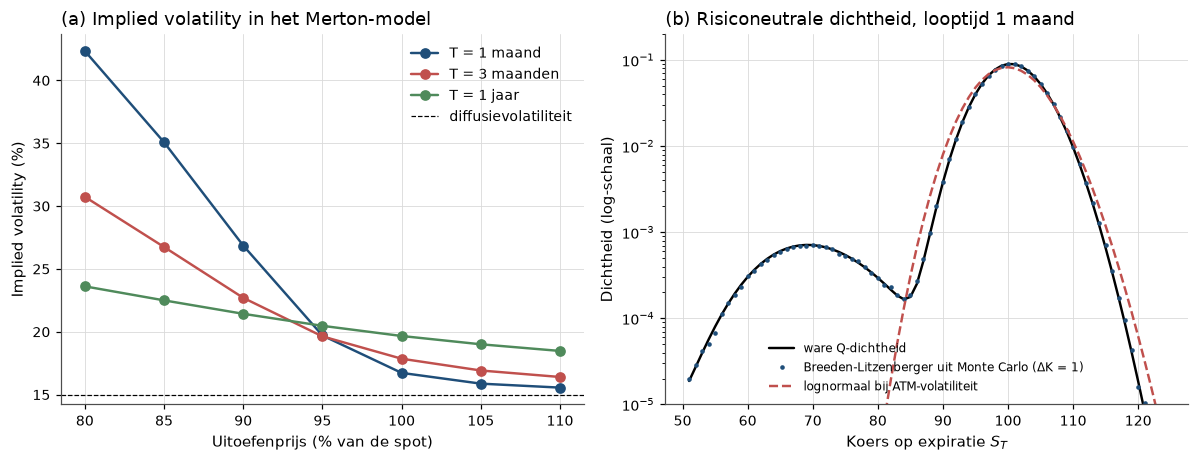

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for i, col in enumerate(smirk_table.columns):
    axes[0].plot(100 * smirk_table.index, 100 * smirk_table[col], "o-", color=hap.plotting.COLORS[i], label=col)
axes[0].axhline(100 * SIGMA_SIM, color="black", lw=0.8, ls="--", label="diffusievolatiliteit")
axes[0].set_title("(a) Implied volatility in het Merton-model")
axes[0].set_xlabel("Uitoefenprijs (% van de spot)")
axes[0].set_ylabel("Implied volatility (%)")
axes[0].legend()

K_mid, dens_mc, true = bl_curves[(1.0, "Monte Carlo, 2 mln paden")]
_, dens_noise, _ = bl_curves[(0.25, "exact + afronding 0,5 cent")]
lognormal = stats.lognorm.pdf(K_mid, s=smirk_table.loc[1.00, "T = 1 maand"] * np.sqrt(T_BL),
                              scale=100.0 * np.exp((R_SIM - 0.5 * smirk_table.loc[1.00, "T = 1 maand"] ** 2) * T_BL))
axes[1].plot(K_mid, true, color="black", lw=1.6, label="ware Q-dichtheid")
axes[1].plot(K_mid, dens_mc, ".", ms=4, color=hap.plotting.COLORS[0], label="Breeden-Litzenberger uit Monte Carlo (ΔK = 1)")
axes[1].plot(K_mid, lognormal, color=hap.plotting.COLORS[1], ls="--", label="lognormaal bij ATM-volatiliteit")
axes[1].set_yscale("log")
axes[1].set_ylim(1e-5, 0.2)
axes[1].set_title("(b) Risiconeutrale dichtheid, looptijd 1 maand")
axes[1].set_xlabel("Koers op expiratie $S_T$")
axes[1].set_ylabel("Dichtheid (log-schaal)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

:::{figure} #cel-opties-crashrisico-merton
:label: fig-opties-crashrisico-merton
:width: 100%

Links: één crashtoestand volstaat voor een smirk die steil is bij korte en vlak bij lange
looptijden. Rechts: de risiconeutrale dichtheid heeft een tweede bult rond een koers van
70, de crash, die de lognormale verdeling met dezelfde at-the-money-volatiliteit volledig
mist; Breeden-Litzenberger vindt haar uit gesimuleerde prijzen terug.
:::

Met exacte prijzen daalt de fout met $\Delta K^2$; met Monte Carlo-prijzen blijft ze bij
$\Delta K = 0{,}25$ op $0{,}00012$ steken (simulatieruis). Met een halve cent afronding
explodeert ze: de RMSE is $0{,}002$ bij $\Delta K = 2$, $0{,}007$
bij $\Delta K = 1$ en $0{,}113$ bij $\Delta K = 0{,}25$ — groter dan de hoogste waarde
van de dichtheid zelf ($0{,}09$), een factor 57 bij een factor 64 in $1/\Delta K^2$. Dichter
liggende uitoefenprijzen maken het dus erger, tenzij men eerst glad strijkt; daarom fitten
we in de replicatie eerst een smile.

### (b) Dertig jaar puts verkopen

Nu de werkelijke maat. Een belegger verkoopt elke maand (21 handelsdagen) een put op 5%
onder de koers, en in een tweede variant at-the-money zoals de Cboe PutWrite-index. In de
*gecollateraliseerde* variant staat de uitoefenprijs in kas: de belegger kan niet failliet,
en het rendement is premie plus rente min uitbetaling, gedeeld door $K$. In de
*gehefboomde* variant stort hij een veelvoud van een gestileerde marge-eis (premie plus
het maximum van 15% van de index min het bedrag waarmee de put out-of-the-money is, en
10% van de uitoefenprijs; gestileerd, niet de exacte beursregel), wordt hij dagelijks
gewaardeerd met [](#eq-opties-crashrisico-merton), en wordt hij *uitgeschud* (gedwongen
tegen de dagprijs terug te kopen en te stoppen) zodra zijn vermogen onder de eis zakt.
Tweeduizend paden van dertig jaar; prijzen uit $\mathbb Q$, koersen uit $\mathbb P$; een
crash is een sprong van meer dan $-15\%$.

In [6]:
def merton_put_fast(S, K, tau):
    """Merton put price with the simulation parameters, truncated at 8 jumps (enough for tau <= 1 month)."""
    return merton_price(S, K, tau, R_SIM, SIGMA_SIM, LAM_Q, MU_J, DELTA_J, kind="put", n_max=8)


def margin_requirement(S, K, P):
    """Stylised naked short-put margin: premium plus max(15% of spot minus OTM amount, 10% of strike)."""
    return P + np.maximum(0.15 * S - np.maximum(S - K, 0.0), 0.10 * K)


N_PATHS, YEARS, DAYS_M, OTM = 2000, 30, 21, 0.05
DT, TAU = 1 / 252, 21 / 252
MULTIPLES = np.array([10.0, 5.0, 3.0, 2.0, 1.5])[:, None]      # capital as multiple of initial margin
MU_P = R_SIM + ETA_SIGMA + jump_premium                        # physical expected return


def step(S):
    """One trading day of the physical jump-diffusion; returns new price and a crash flag (jump below -15%)."""
    n = rng.poisson(LAM_P * DT, len(S))
    jump = n * MU_J + np.sqrt(n) * DELTA_J * rng.standard_normal(len(S))
    diffusion = (MU_P - LAM_P * KAPPA - 0.5 * SIGMA_SIM**2) * DT + SIGMA_SIM * np.sqrt(DT) * rng.standard_normal(len(S))
    return S * np.exp(diffusion + jump), (n > 0) & (jump < np.log(0.85))


S = np.full(N_PATHS, 100.0)
equity = np.ones((len(MULTIPLES), N_PATHS))
alive = np.ones_like(equity, dtype=bool)
put_ret, atm_ret, mkt_ret, crash, notional = [], [], [], [], []
for month in range(12 * YEARS):
    S0 = S.copy()
    K, K_atm = (1 - OTM) * S0, S0
    P0, P0_atm = merton_put_fast(S0, K, TAU), merton_put_fast(S0, K_atm, TAU)
    contracts = equity / (MULTIPLES * margin_requirement(S0, K, P0))
    cash = equity + contracts * P0
    notional.append(np.where(alive, contracts * K / np.maximum(equity, 1e-12), np.nan))
    crashed = np.zeros(N_PATHS, dtype=bool)
    for day in range(1, DAYS_M + 1):
        S, flag = step(S)
        crashed |= flag
        cash = cash * np.exp(R_SIM * DT)
        P_t = merton_put_fast(S, K, TAU - day * DT) if day < DAYS_M else np.maximum(K - S, 0.0)
        marked = cash - contracts * P_t
        if day < DAYS_M:                                        # daily margin check, forced close-out
            call = alive & (marked < contracts * margin_requirement(S, K, P_t))
        else:
            call = alive & (marked <= 0)
        equity = np.where(alive & ~call & (day == DAYS_M), marked, equity)
        equity = np.where(call, np.maximum(marked, 0.0), equity)
        alive &= ~call
    growth_rf = np.exp(R_SIM * TAU)
    put_ret.append(((K + P0) * growth_rf - np.maximum(K - S, 0.0)) / K - 1)
    atm_ret.append(((K_atm + P0_atm) * growth_rf - np.maximum(K_atm - S, 0.0)) / K_atm - 1)
    mkt_ret.append(S / S0 - 1)
    crash.append(crashed)

put_ret, atm_ret, mkt_ret, crash = map(np.array, (put_ret, atm_ret, mkt_ret, crash))
rf_month = np.exp(R_SIM * TAU) - 1
p0_start = float(merton_put_fast(100.0, 95.0, TAU))
print(f"{N_PATHS} paden x {YEARS} jaar; crashes per jaar: {crash.mean() * 12:.4f}")
print(f"put 5% OTM bij S = 100: premie {p0_start:.4f}, initiële marge "
      f"{float(margin_requirement(100.0, 95.0, p0_start)):.4f}")

2000 paden x 30 jaar; crashes per jaar: 0.0762
put 5% OTM bij S = 100: premie 0.5113, initiële marge 10.5113


In [7]:
def path_stats(returns):
    """Annualised Sharpe ratio, monthly skewness and maximum drawdown per path (columns)."""
    excess = returns - rf_month
    wealth = np.cumprod(1 + returns, axis=0)
    return {"Sharpe": np.sqrt(12) * excess.mean(0) / excess.std(0, ddof=1),
            "scheefheid": stats.skew(returns, axis=0),
            "max drawdown": (wealth / np.maximum.accumulate(wealth, axis=0) - 1).min(0)}


strategies = {"markt": mkt_ret, "short put ATM, gecollateraliseerd": atm_ret,
              "short put 5% OTM, gecollateraliseerd": put_ret}
pooled = {name: np.sqrt(12) * (r - rf_month).mean() / (r - rf_month).std() for name, r in strategies.items()}
sim_summary = pd.DataFrame(
    {name: {"Sharpe (populatie)": pooled[name],
            "Sharpe, mediaan per 30 jaar": np.median(path_stats(r)["Sharpe"]),
            "Sharpe, 5%-kwantiel": np.quantile(path_stats(r)["Sharpe"], 0.05),
            "Sharpe, 95%-kwantiel": np.quantile(path_stats(r)["Sharpe"], 0.95),
            "scheefheid (mediaan)": np.median(path_stats(r)["scheefheid"]),
            "max drawdown (mediaan)": np.median(path_stats(r)["max drawdown"])}
     for name, r in strategies.items()}
).T
margin_summary = pd.DataFrame(
    {"kapitaal / initiële marge": MULTIPLES.ravel(),
     "notionele hefboom (gem.)": np.nanmean(np.array(notional), axis=(0, 2)),
     "P(uitgeschud binnen 30 jaar)": 1 - alive.mean(1)}
).set_index("kapitaal / initiële marge")
sim_summary.round(3)

,Sharpe (populatie),"Sharpe, mediaan per 30 jaar","Sharpe, 5%-kwantiel","Sharpe, 95%-kwantiel",scheefheid (mediaan),max drawdown (mediaan)
markt,0.355,0.361,0.059,0.691,-1.317,-0.469
"short put ATM, gecollateraliseerd",0.361,0.389,0.047,0.888,-5.342,-0.374
"short put 5% OTM, gecollateraliseerd",0.326,0.365,-0.003,1.793,-10.485,-0.316


In de populatie — alle tweeduizend paden samen, zestigduizend jaar — heeft de
gecollateraliseerde verkoper van 5%-OTM-puts een Sharpe-ratio van $0{,}33$, de
at-the-money-verkoper $0{,}36$ en de markt $0{,}36$. In onze kalibratie zijn alleen de
sprongen duurder onder $\mathbb Q$; zonder de premie op volatiliteitsrisico die
Santa-Clara en Yan daarnaast vinden, is dit een ondergrens. De maandelijkse scheefheid van de short put is $-10{,}5$, dicht bij de $-11{,}06$ die
Saretto en Santa-Clara voor hun 10%-OTM-put rapporteren. De mediane maximale drawdown is
$-32\%$ tegen $-47\%$ voor de markt, maar de spreiding van de Sharpe-ratio over
dertig jaar is groot: van $0{,}00$ tot $1{,}79$ tussen het 5%- en 95%-kwantiel, tegen
$0{,}06$ tot $0{,}69$ voor de markt.

In [8]:
margin_summary.round(3)

,notionele hefboom (gem.),P(uitgeschud binnen 30 jaar)
kapitaal / initiële marge,,
10.0,0.904,0.005
5.0,1.808,0.800
3.0,3.013,0.894
2.0,4.519,0.998
1.5,6.025,1.000


De marge-eis bij de start is $10{,}51$ per put op een index van 100, voor een premie van
$0{,}51$. Wie tien keer de marge stort, heeft een notionele hefboom onder één en wordt in
een half procent van de paden uitgeschud. Wie vijf keer de marge stort ($L = 1{,}8$), in
80%; bij drie keer ($L = 3$) in 89%, bij twee keer ($L = 4{,}5$) vrijwel altijd. Volgens
[](#prop-opties-crashrisico-ruine) vraagt ruïne bij $L = 1{,}8$ een crash van ruim 58%, maar
de margin call komt veel eerder: een sprong van $-30\%$ maakt de put 25 punten
in-the-money, en de nieuwe eis is premie plus 15% van de lagere index. Uitgeschud worden
is hier nagenoeg de eerste crash meemaken.

Tot slot motief 1. Welke Sharpe-ratio ziet een onderzoeker die twintig jaar data heeft?

In [9]:
window = 240
ex20 = put_ret[:window] - rf_month
sharpe20 = np.sqrt(12) * ex20.mean(0) / ex20.std(0, ddof=1)
no_crash = crash[:window].sum(0) == 0
p_theory = np.exp(-window * crash.mean())
pd.DataFrame(
    {"fractie steekproeven": [no_crash.mean(), 1 - no_crash.mean()],
     "Sharpe mediaan": [np.median(sharpe20[no_crash]), np.median(sharpe20[~no_crash])],
     "Sharpe 90%-kwantiel": [np.quantile(sharpe20[no_crash], 0.9), np.quantile(sharpe20[~no_crash], 0.9)],
     "fractie Sharpe > 2 x populatie": [np.mean(sharpe20[no_crash] > 2 * pooled["short put 5% OTM, gecollateraliseerd"]),
                                        np.mean(sharpe20[~no_crash] > 2 * pooled["short put 5% OTM, gecollateraliseerd"])]},
    index=["geen crash in 20 jaar", "minstens één crash"],
).round(3)

,fractie steekproeven,Sharpe mediaan,Sharpe 90%-kwantiel,fractie Sharpe > 2 x populatie
geen crash in 20 jaar,0.214,1.852,3.051,1.000
minstens één crash,0.786,0.284,0.730,0.135


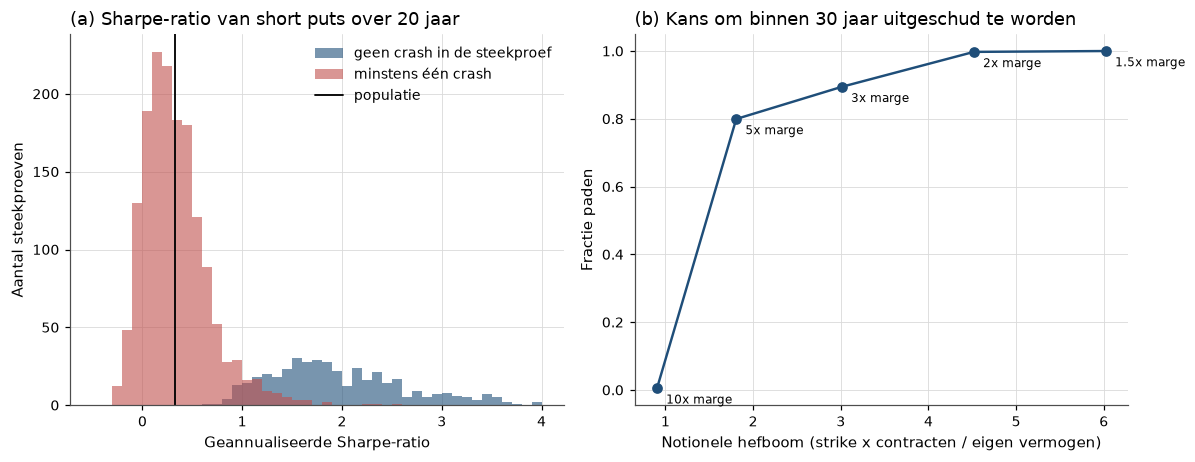

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.linspace(-0.5, 4.0, 46)
axes[0].hist(sharpe20[no_crash], bins=bins, alpha=0.6, color=hap.plotting.COLORS[0], label="geen crash in de steekproef")
axes[0].hist(sharpe20[~no_crash], bins=bins, alpha=0.6, color=hap.plotting.COLORS[1], label="minstens één crash")
axes[0].axvline(pooled["short put 5% OTM, gecollateraliseerd"], color="black", lw=1.2, label="populatie")
axes[0].set_title("(a) Sharpe-ratio van short puts over 20 jaar")
axes[0].set_xlabel("Geannualiseerde Sharpe-ratio")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
axes[1].plot(margin_summary["notionele hefboom (gem.)"], margin_summary["P(uitgeschud binnen 30 jaar)"], "o-")
for mult, row in margin_summary.iterrows():
    axes[1].annotate(f"{mult:g}x marge", (row["notionele hefboom (gem.)"], row["P(uitgeschud binnen 30 jaar)"]),
                     textcoords="offset points", xytext=(6, -10), fontsize=8)
axes[1].set_title("(b) Kans om binnen 30 jaar uitgeschud te worden")
axes[1].set_xlabel("Notionele hefboom (strike x contracten / eigen vermogen)")
axes[1].set_ylabel("Fractie paden")
fig.tight_layout()
plt.show()

:::{figure} #cel-opties-crashrisico-shortput
:label: fig-opties-crashrisico-shortput
:width: 100%

Links: twintig jaar short puts zonder crash geven een Sharpe-ratio rond de twee, met
één crash rond de populatiewaarde van een derde. De twee verdelingen overlappen nauwelijks:
de steekproef-Sharpe meet vooral óf er een crash in de steekproef zat. Rechts: de kans om
uitgeschud te worden stijgt steil met de hefboom, lang voordat het vermogen op nul staat.
:::

In 21,4% van de twintigjarige steekproeven ([](#fig-opties-crashrisico-shortput)) komt
geen enkele crash voor, precies wat een
Poisson-proces met $0{,}076$ crashes per jaar voorspelt ($e^{-20 \cdot 0{,}076} = 0{,}22$). In
die steekproeven is de mediane Sharpe-ratio $1{,}85$, meer dan vijf keer de populatiewaarde
van $0{,}33$, en in *elke* steekproef zonder crash is ze meer dan het dubbele. Een
onderzoeker met zo'n steekproef rapporteert naar alle maatstaven een significante anomalie:
de gebruikelijke standaardfout van een Sharpe-ratio over twintig jaar is ongeveer
$\sqrt{(1 + 1{,}85^2/2)/20} = 0{,}35$, dus $t \approx 5$, maar die formule veronderstelt
dunne staarten. Dat is de "extreme sampling uncertainty" van Broadie, Chernov en Johannes,
en het praktijkmotief in cijfers: een steekproef zonder crash leert de verkoper iets wat de
prijs niet weet, en het is niet waar.

## Replicatie op echte data

### De risiconeutrale verdeling van SPY

```{admonition} Replicatie
:class: seealso

**Bron.** Breeden en Litzenberger, *Prices of State-Contingent Claims Implicit in Option
Prices*, Journal of Business 1978 {cite}`BreedenLitzenberger1978`; Bakshi, Kapadia en
Madan, *Stock Return Characteristics, Skew Laws, and the Differential Pricing of
Individual Equity Options*, Review of Financial Studies 2003 {cite}`BakshiKapadiaMadan2003`.

**Wat.** De methode van Breeden en Litzenberger, en de bevinding van Bakshi, Kapadia en
Madan dat de risiconeutrale verdeling van de index sterk linksscheef is. Hun tabellen
hebben we niet ingezien; we toetsen alleen het teken, en vergelijken met de werkelijke
verdeling over dezelfde horizon.

**Data hier.** Een momentopname van de SPY-optieketen van 11 september 2026 (28
expiraties) via `hap.data.yahoo_options("SPY", 28)`, met de expiraties van 9 oktober
(28 dagen) en 18 december 2026 (98 dagen); rente `hap.data.fred("DGS3MO")`; historische
maand- en kwartaalrendementen uit `hap.data.market_daily()`, 1926–2026.

**Verschil met het origineel.** Bakshi, Kapadia en Madan gebruikten OEX-opties en
modelvrije momenten; wij gebruiken één dag, Amerikaanse opties op een ETF, een SVI-fit
(de vijfparametervorm van Gatheral voor de totale implied variance) binnen het bereik van
genoteerde uitoefenprijzen, en daarna [](#eq-opties-crashrisico-bl). Buiten dat bereik
extrapoleren we niet; de massa die buiten valt, rapporteren we.

**Verwachte afwijking.** Niveaus hangen van de dag af. Het teken moet identiek zijn: de
risiconeutrale scheefheid is voor beide looptijden negatief en negatiever dan de
historische scheefheid over 1926–2026 op dezelfde horizon; de dichtheid is nergens
negatief. Is de scheefheid positief, dan zit de fout in de code.
```

In [11]:
chain = hap_data.yahoo_options("SPY", 28)
spot = float(chain["spot"].iloc[0])
valuation = pd.Timestamp(chain.index.max().date()) + pd.Timedelta(hours=16)
r_cc = float(np.log1p(hap_data.fred("DGS3MO")["DGS3MO"].dropna().loc[:valuation].iloc[-1] / 100))

quotes = chain.reset_index()
quotes = quotes[(quotes["bid"] > 0) & (quotes["ask"] > quotes["bid"])].copy()
quotes["mid"] = 0.5 * (quotes["bid"] + quotes["ask"])
quotes["T"] = (quotes["expiry"] + pd.Timedelta(hours=16) - valuation).dt.total_seconds() / (365.25 * 86400)


def smile_for_expiry(target_T):
    """OTM quotes, parity forward and implied vols for the expiry closest to target_T."""
    expiry_T = quotes.groupby("expiry")["T"].first()
    expiry = expiry_T.index[np.argmin(np.abs(expiry_T.to_numpy() - target_T))]
    g = quotes[quotes["expiry"] == expiry]
    T, DF = float(g["T"].iloc[0]), float(np.exp(-r_cc * g["T"].iloc[0]))
    wide = g.pivot_table(index="strike", columns="kind", values="mid").dropna()
    near = wide[np.abs(np.log(wide.index / spot)) < 0.05]
    F = float(np.median(near.index + (near["call"] - near["put"]) / DF))
    otm = g[((g["kind"] == "put") & (g["strike"] < F)) | ((g["kind"] == "call") & (g["strike"] >= F))]
    otm = otm[otm["bid"] >= 0.05].sort_values("strike").copy()
    otm["iv"] = implied_vol(otm["mid"].to_numpy(), F, otm["strike"].to_numpy(), T, DF, otm["kind"].to_numpy())
    otm["k"] = np.log(otm["strike"] / F)
    atm = float(np.interp(0.0, otm["k"], otm["iv"]))
    otm = otm[otm["k"].between(-5 * atm * np.sqrt(T), 3 * atm * np.sqrt(T))]
    return {"expiry": expiry, "T": T, "DF": DF, "F": F, "atm": atm, "otm": otm}


def svi_total_variance(k, a, b, rho, m, s):
    """Gatheral's raw SVI parametrisation of total implied variance w(k) = sigma^2 T."""
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s**2))


def rn_density(sm, n_grid=2001):
    """Breeden-Litzenberger density of log(S_T/F) from an SVI smile, inside the quoted strike range."""
    otm, T = sm["otm"], sm["T"]
    k_obs, w_obs = otm["k"].to_numpy(), otm["iv"].to_numpy() ** 2 * T
    fit = optimize.least_squares(lambda p: svi_total_variance(k_obs, *p) - w_obs,
                                 x0=[w_obs.min(), 0.1, -0.5, 0.0, 0.1],
                                 bounds=([-1, 0, -0.999, -1, 1e-4], [1, 5, 0.999, 1, 2]))

    def smile(kk):
        return np.sqrt(np.maximum(svi_total_variance(kk, *fit.x), 1e-10) / T)

    k = np.linspace(k_obs.min(), k_obs.max(), n_grid)
    K = sm["F"] * np.exp(k)
    C = black_price(sm["F"], K, T, smile(k), sm["DF"])
    dens_K = np.gradient(np.gradient(C, K), K) / sm["DF"]
    rmse = np.sqrt(np.mean((smile(k_obs) - otm["iv"].to_numpy()) ** 2))
    inner = slice(3, -3)                                         # one-sided differences at the grid edges
    return k[inner], (dens_K * K)[inner], smile, rmse            # density of k = log(S_T / F)


def moments(x, f):
    """Mass, mean, annualisable s.d., skewness and excess kurtosis of a density on a grid."""
    mass = np.trapezoid(f, x)
    f = f / mass
    mu = np.trapezoid(x * f, x)
    sd = np.sqrt(np.trapezoid((x - mu) ** 2 * f, x))
    return {"massa binnen strikes": mass, "sd": sd,
            "scheefheid": np.trapezoid((x - mu) ** 3 * f, x) / sd**3,
            "exces-kurtosis": np.trapezoid((x - mu) ** 4 * f, x) / sd**4 - 3}


smiles = {label: smile_for_expiry(T) for label, T in (("1 maand", 1 / 12), ("3 maanden", 0.25))}
print(f"waarderingsmoment {valuation}, spot {spot:.2f}, r = {r_cc:.4f}")

waarderingsmoment 2026-09-11 16:00:00, spot 764.29, r = 0.0382


In [12]:
daily_log = np.log1p(hap_data.market_daily()["Mkt"])
rn_rows, densities = {}, {}
for label, sm in smiles.items():
    k, dens, smile, rmse = rn_density(sm)
    densities[label] = (k, dens, smile)
    mom = moments(k, dens)
    h = int(round(sm["T"] * 252))
    rn_rows[f"Q, {label} ({sm['expiry'].date()})"] = {
        "T (jaar)": sm["T"], "aantal opties": len(sm["otm"]), "fitfout (vol)": rmse,
        "massa binnen strikes": mom["massa binnen strikes"],
        "min. dichtheid": dens.min(), "vol (jaarbasis)": mom["sd"] / np.sqrt(sm["T"]),
        "scheefheid": mom["scheefheid"], "exces-kurtosis": mom["exces-kurtosis"]}
    for period, sample in (("1926-2026", daily_log), ("1990-2026", daily_log.loc["1990":])):
        agg = sample.rolling(h).sum().iloc[h - 1::h]
        rn_rows[f"P, {label}, {period}"] = {
            "T (jaar)": h / 252, "aantal opties": np.nan, "fitfout (vol)": np.nan,
            "massa binnen strikes": np.nan, "min. dichtheid": np.nan,
            "vol (jaarbasis)": agg.std() * np.sqrt(252 / h), "scheefheid": agg.skew(), "exces-kurtosis": agg.kurt()}
pd.DataFrame(rn_rows).T.round(4)

,T (jaar),aantal opties,fitfout (vol),massa binnen strikes,min. dichtheid,vol (jaarbasis),scheefheid,exces-kurtosis
"Q, 1 maand (2026-10-09)",0.0767,123.0,0.0011,0.9911,0.1027,0.1233,-1.2287,2.7073
"P, 1 maand, 1926-2026",0.0754,NaN,NaN,NaN,NaN,0.1764,-0.6088,5.3822
"P, 1 maand, 1990-2026",0.0754,NaN,NaN,NaN,NaN,0.1515,-0.7687,2.2930
"Q, 3 maanden (2026-12-18)",0.2683,86.0,0.0008,0.9871,0.0140,0.1436,-1.2955,2.9589
"P, 3 maanden, 1926-2026",0.2698,NaN,NaN,NaN,NaN,0.1855,-0.5526,6.3015
"P, 3 maanden, 1990-2026",0.2698,NaN,NaN,NaN,NaN,0.1630,-1.3266,5.3022


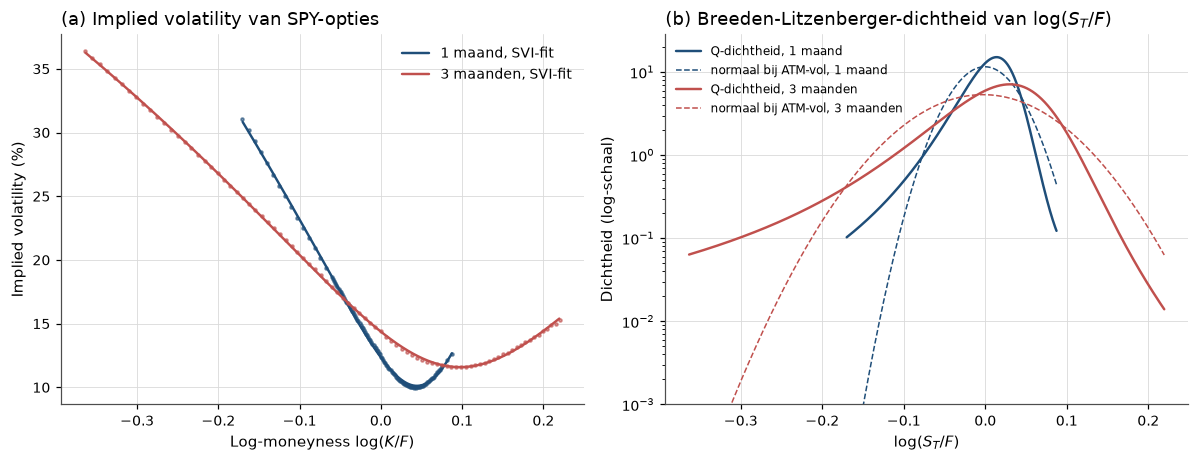

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for i, (label, sm) in enumerate(smiles.items()):
    k, dens, smile = densities[label]
    otm = sm["otm"]
    axes[0].plot(otm["k"], 100 * otm["iv"], ".", ms=4, color=hap.plotting.COLORS[i], alpha=0.6)
    axes[0].plot(k, 100 * smile(k), color=hap.plotting.COLORS[i], label=f"{label}, SVI-fit")
    x = np.linspace(k.min(), k.max(), 400)
    normal = stats.norm.pdf(x, -0.5 * sm["atm"] ** 2 * sm["T"], sm["atm"] * np.sqrt(sm["T"]))
    axes[1].plot(k, dens, color=hap.plotting.COLORS[i], label=f"Q-dichtheid, {label}")
    axes[1].plot(x, normal, color=hap.plotting.COLORS[i], ls="--", lw=1, label=f"normaal bij ATM-vol, {label}")
axes[0].set_title("(a) Implied volatility van SPY-opties")
axes[0].set_xlabel(r"Log-moneyness $\log(K/F)$")
axes[0].set_ylabel("Implied volatility (%)")
axes[0].legend()
axes[1].set_yscale("log")
axes[1].set_ylim(1e-3, None)
axes[1].set_title("(b) Breeden-Litzenberger-dichtheid van $\\log(S_T/F)$")
axes[1].set_xlabel(r"$\log(S_T/F)$")
axes[1].set_ylabel("Dichtheid (log-schaal)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

:::{figure} #cel-opties-crashrisico-spy-dichtheid
:label: fig-opties-crashrisico-spy-dichtheid
:width: 100%

Links: de SVI-fit volgt de genoteerde implied volatilities op een tiende volatiliteitspunt.
Rechts: de risiconeutrale dichtheid van SPY heeft een linkerstaart die ordes van grootte
dikker is dan de normale verdeling met dezelfde at-the-money-volatiliteit, en een
rechterstaart die dunner is.
:::

De SVI-fit wijkt $0{,}11$ en $0{,}08$ volatiliteitspunt af, de dichtheid
([](#fig-opties-crashrisico-spy-dichtheid)) is nergens negatief, en binnen de genoteerde
uitoefenprijzen ligt $99{,}1\%$ en $98{,}7\%$ van de massa. De risiconeutrale scheefheid is $-1{,}23$ op een
maand en $-1{,}30$ op een kwartaal. Historisch was de scheefheid van niet-overlappende
maandrendementen over 1926–2026 $-0{,}61$ en van kwartaalrendementen $-0{,}55$: de
optiemarkt maakt de linkerstaart ongeveer twee keer zo scheef als een eeuw data. Twee
kanttekeningen. Over 1990–2026 is de historische kwartaalscheefheid $-1{,}33$, even
negatief als de risiconeutrale: welke crashes in de steekproef zitten, bepaalt de
vergelijking (motief 1 in het derde moment). En de exces-kurtosis ($2{,}7$ en $3{,}0$) ligt
*onder* de historische ($5{,}4$ en $6{,}3$), omdat we de staart voorbij de laagste put
afsnijden, op een rustige dag. Het teken van de scheefheid is robuust, de grootte niet:
rechtstreeks uit de prijzen ([](#prop-opties-crashrisico-momenten)) is ze $-2{,}1$ en
$-2{,}3$ ([](#ex-opties-crashrisico-2)).

### De variance risk premium als voorspeller

```{admonition} Replicatie
:class: seealso

**Bron.** Bollerslev, Tauchen en Zhou, *Expected Stock Returns and Variance Risk Premia*,
Review of Financial Studies 2009 {cite}`BollerslevTauchenZhou2009`.

**Wat.** Tabel 2: regressies van het geannualiseerde excess rendement over $h$ maanden op
de variance risk premium, januari 1990 – december 2007, met Hodrick-$t$-waarden.
Gepubliceerd: bij $h = 1$ helling $0{,}39$ ($t = 1{,}76$, aangepaste $R^2$ $1{,}07\%$), bij
$h = 3$ $0{,}47$ ($t = 2{,}86$, $6{,}82\%$), bij $h = 6$ $0{,}30$ ($2{,}15$, $5{,}42\%$), bij
$h = 12$ $0{,}12$ ($1{,}00$, $1{,}23\%$), met "the largest t-statistic and maximum R2 occurring
at the quarterly horizon".

**Data hier.** $\mathrm{VRP}_t = \mathrm{VIX}_t^2/12 - \mathrm{RV}_t$ in maand-$\%^2$, met de
VIX van FRED (`hap.data.fred("VIXCLS")`) op maandeinde en $\mathrm{RV}_t$ de som van
gekwadrateerde dagelijkse log-rendementen van de French-marktportefeuille in maand $t$
(`hap.data.market_daily()`); excess log-rendementen uit `hap.data.market_monthly()`.

**Verschil met het origineel.** BTZ berekenen $\mathrm{RV}$ uit vijfminutenrendementen van de
S&P 500; onze dagelijkse versie is ruiziger. Onze $t$-waarden zijn Newey-West met $h-1$
vertragingen (`hap.long_horizon_regression`), die bij overlappende waarnemingen doorgaans
hoger uitvallen dan Hodrick-$t$-waarden. We verlengen de steekproef tot juli 2026.

**Verwachte afwijking.** Op 1990–2007 een positieve helling bij elke horizon, in de orde
van de gepubliceerde, met $t > 2$ bij de kwartaalhorizon en de hoogste $R^2$ tussen drie en
zes maanden. Na 2007 zwakker. Een negatieve helling op 1990–2007 betekent een fout in de
code.
```

In [14]:
vix = hap_data.fred("VIXCLS")["VIXCLS"].dropna()
implied_var = (vix.resample("ME").last() ** 2 / 12).rename("IV")            # monthly, %^2
realized_var = ((100 * daily_log) ** 2).resample("ME").sum().rename("RV")   # monthly, %^2
market_m = hap_data.market_monthly()
excess_log = (np.log1p(market_m["Mkt"]) - np.log1p(market_m["RF"])).rename("rx")
btz = implied_var.to_frame().join(realized_var, how="inner").join(excess_log, how="inner").dropna()
btz["VRP"] = btz["IV"] - btz["RV"]

btz_rows = []
for period, sl in (("1990-2007", slice("1990", "2007")), ("1990-2026", slice("1990", None)),
                   ("2008-2026", slice("2008", None))):
    sample = btz.loc[sl]
    res = hap.long_horizon_regression(1200 * sample["rx"], sample["VRP"], horizons=(1, 2, 3, 4, 6, 12),
                                      method="newey-west")
    res["helling (BTZ-schaal)"] = res["beta"] / res.index   # annualised % return averaged over h months
    res["adj. R2"] = 1 - (1 - res["r2"]) * (res["nobs"] - 1) / (res["nobs"] - 2)
    res["periode"] = period
    btz_rows.append(res.reset_index())
btz_table = pd.concat(btz_rows).set_index(["periode", "horizon"])
print(f"{btz.index[0]:%Y-%m} t/m {btz.index[-1]:%Y-%m}: gemiddelde IV {btz['IV'].mean():.2f}, "
      f"RV {btz['RV'].mean():.2f}, VRP {btz['VRP'].mean():.2f} (maand-%^2); VRP > 0 in "
      f"{(btz['VRP'] > 0).mean():.1%} van de maanden")
btz_table.round(3)

1990-01 t/m 2026-07: gemiddelde IV 36.12, RV 27.29, VRP 8.83 (maand-%^2); VRP > 0 in 86.6% van de maanden


beta     se  tstat     r2  nobs  helling (BTZ-schaal)  \
periode   horizon                                                           
1990-2007 1        0.424  0.256  1.655  0.018   215                 0.424   
          2        1.163  0.328  3.546  0.065   214                 0.582   
          3        1.335  0.363  3.679  0.058   213                 0.445   
          4        1.643  0.497  3.304  0.067   212                 0.411   
          6        2.076  0.562  3.694  0.076   210                 0.346   
          12       2.640  1.178  2.241  0.057   204                 0.220   
1990-2026 1        0.061  0.198  0.309  0.002   438                 0.061   
          2        0.113  0.294  0.383  0.003   437                 0.056   
          3        0.236  0.396  0.597  0.008   436                 0.079   
          4        0.257  0.495  0.518  0.007   435                 0.064   
          6        0.165  0.431  0.383  0.002   433                 0.027   
          12      -0.220  0.389 -0.566  0.002   427                -0.018   
2008-2026 1        0.030  0.203  0.145  0.001   222                 0.030   
          2        0.010  0.275  0.035  0.000   221                 0.005   
          3        0.136  0.390  0.349  0.004   220                 0.045   
          4        0.129  0.491  0.263  0.003   219                 0.032   
          6       -0.004  0.389 -0.011  0.000   217                -0.001   
          12      -0.468  0.259 -1.810  0.014   211                -0.039   

                   adj. R2  
periode   horizon           
1990-2007 1          0.013  
          2          0.061  
          3          0.053  
          4          0.063  
          6          0.072  
          12         0.053  
1990-2026 1         -0.001  
          2          0.000  
          3          0.006  
          4          0.005  
          6         -0.000  
          12        -0.001  
2008-2026 1         -0.004  
          2         -0.005  
          3         -0.000  
          4         -0.002  
          6         -0.005  
          12         0.009

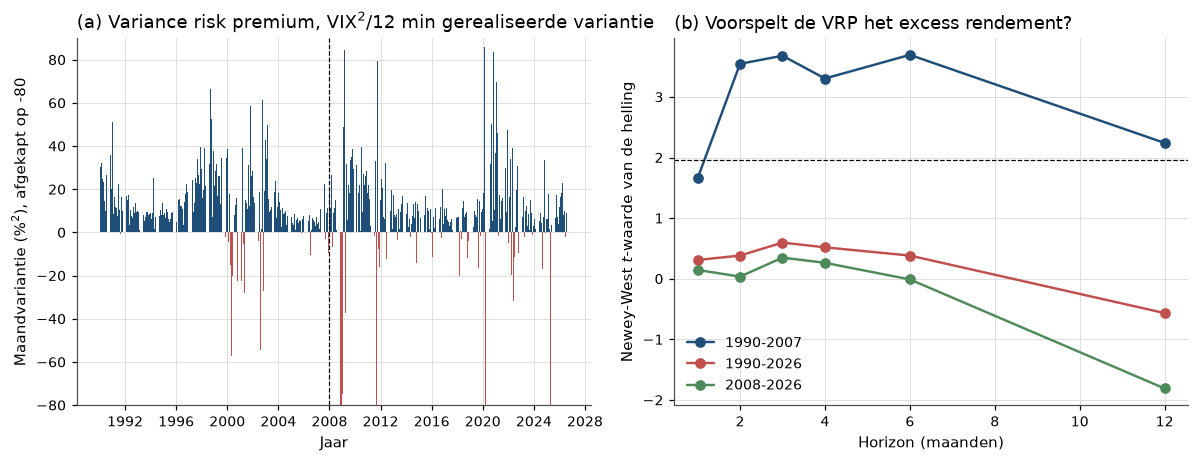

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(btz.index, btz["VRP"], width=25,
            color=np.where(btz["VRP"] > 0, hap.plotting.COLORS[0], hap.plotting.COLORS[1]))
axes[0].set_ylim(-80, 90)
axes[0].axvline(pd.Timestamp("2007-12-31"), color="black", lw=0.8, ls="--")
axes[0].set_title("(a) Variance risk premium, VIX$^2$/12 min gerealiseerde variantie")
axes[0].set_xlabel("Jaar")
axes[0].set_ylabel("Maandvariantie (%$^2$), afgekapt op -80")
for i, period in enumerate(["1990-2007", "1990-2026", "2008-2026"]):
    axes[1].plot(btz_table.loc[period].index, btz_table.loc[period, "tstat"], "o-",
                 color=hap.plotting.COLORS[i], label=period)
axes[1].axhline(1.96, color="black", lw=0.8, ls="--")
axes[1].set_title("(b) Voorspelt de VRP het excess rendement?")
axes[1].set_xlabel("Horizon (maanden)")
axes[1].set_ylabel("Newey-West $t$-waarde van de helling")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-opties-crashrisico-btz
:label: fig-opties-crashrisico-btz
:width: 100%

Links: de variance risk premium is in 87% van de maanden positief; de negatieve maanden
zijn crisismaanden waarin de gerealiseerde variantie de VIX inhaalt (de twee diepste, maart
2020 en oktober 2008, zijn afgekapt). Rechts: de voorspelkracht die Bollerslev, Tauchen en Zhou tot 2007
vonden, is in de steekproef daarna verdwenen.
:::

Over 1990–2007 komen de hellingen dicht bij de gepubliceerde: $0{,}42$ bij één maand
(tegen $0{,}39$), $0{,}45$ bij drie maanden (tegen $0{,}47$), $0{,}35$ bij zes (tegen $0{,}30$)
en $0{,}22$ bij twaalf (tegen $0{,}12$). De aangepaste $R^2$ is $1{,}3\%$, $5{,}3\%$, $7{,}2\%$
en $5{,}3\%$, met het maximum bij zes maanden in plaats van drie; de Newey-West-$t$-waarden
($1{,}66$, $3{,}68$, $3{,}69$, $2{,}24$) zijn zoals verwacht hoger dan die van Hodrick. Het
teken, de orde van grootte en de bult tussen één en twaalf maanden zijn gerepliceerd.

Daarna houdt het op. Over 1990–2026 is geen enkele helling significant ($t \leq 0{,}6$),
en over 2008–2026 is de kwartaalhelling $0{,}05$ met $t = 0{,}35$. Het mechanisme is zichtbaar
in [](#fig-opties-crashrisico-btz): in oktober 2008 en maart 2020 schoot de gerealiseerde variantie ver
boven de VIX, werd de premie diep negatief, en volgden er juist hoge rendementen. Een
voorspeller die de crash zelf als lage premie meet, voorspelt verkeerd op de momenten die
voor het gemiddelde tellen. Het weerlegt [](#prop-opties-crashrisico-vrp) niet, maar toont
hoe dun achttien jaar bewijs voor een rendementsvoorspeller is: motief 1, en het patroon
van Goyal en Welch uit [](#04-20-voorspelbaarheid).

### Verkopers van puts in het echt: de Cboe PutWrite-index

```{admonition} Replicatie
:class: seealso

**Bron.** Saretto en Santa-Clara, *Option Strategies: Good Deals and Margin Calls*,
Journal of Financial Markets 2009 {cite}`SarettoSantaClara2009`; Israelov en Nielsen,
*Covered Calls Uncovered*, Financial Analysts Journal 2015 {cite}`IsraelovNielsen2015b`;
Cboe, methodologie van de PutWrite-index {cite}`Cboe2026`.

**Wat.** De bewering dat het verkopen van indexputs een aantrekkelijke risico-rendementsverhouding
heeft met een extreme linkerstaart. De PUT-index verkoopt volgens zijn methodologie
"SPX puts [...] struck at-the-money [...] on a monthly basis", gedekt door een
T-bill-rekening; de BuyWrite-index BXM verkoopt calls op een aandelenportefeuille.

**Data hier.** Dagelijkse niveaus van `^PUT`, `^BXM` en `^SP500TR` via
`hap.data.yahoo(...)`, maandrendementen september 1996 – juni 2026 (358 maanden),
risicovrije rente uit `hap.data.market_monthly()`.

**Verschil met het origineel.** Saretto en Santa-Clara gebruikten individuele
optiecontracten, OTM-puts en expliciete marges; de PUT-index is at-the-money en volledig
gecollateraliseerd, dus zonder hefboom en zonder margin calls. De index heeft 1 juni 1988
als basisdatum en werd op 20 juni 2007 gelanceerd, zodat de waarden daarvoor teruggerekend
zijn; Yahoo levert de reeks pas vanaf augustus 1996.

**Verwachte afwijking.** PUT heeft een lagere volatiliteit dan de S&P 500, een negatievere
scheefheid en een hogere kurtosis. Het verschil in Sharpe-ratio is kleiner dan één
standaardfout. In 2008 en in februari–maart 2020 verliest PUT een groot deel van wat de
index verliest, ondanks een bèta ver onder één.
```

In [16]:
levels = hap_data.yahoo(["^GSPC", "^PUT", "^BXM"], "1986-01-01").join(hap_data.yahoo("^SP500TR", "1986-01-01"))
monthly = levels[["^SP500TR", "^PUT", "^BXM"]].resample("ME").last().pct_change()
monthly.columns = ["S&P 500 (total return)", "PutWrite (PUT)", "BuyWrite (BXM)"]
cboe = monthly.join(market_m["RF"], how="inner").loc["1996-09":"2026-06"].dropna()
cboe_excess = cboe.drop(columns="RF").sub(cboe["RF"], axis=0)

stats_cboe = hap.summary_stats(cboe_excess).drop(columns=["start", "end"]).astype(float)
stats_cboe["SE Sharpe"] = np.sqrt((1 + stats_cboe["sharpe_ann"] ** 2 / 2) / (stats_cboe["nobs"] / 12))
for name in cboe_excess:
    dd = hap.drawdowns(cboe[name])
    fit = hap.newey_west(cboe_excess[name], cboe_excess["S&P 500 (total return)"], lags=3)
    stats_cboe.loc[name, "max drawdown"] = dd.attrs["max_drawdown"]
    stats_cboe.loc[name, "nov 2007 - feb 2009"] = (1 + cboe[name].loc["2007-11":"2009-02"]).prod() - 1
    stats_cboe.loc[name, "feb - mrt 2020"] = (1 + cboe[name].loc["2020-02":"2020-03"]).prod() - 1
    stats_cboe.loc[name, "alpha (jaar)"] = 12 * fit.params.iloc[0]
    stats_cboe.loc[name, "t(alpha)"] = fit.tvalues.iloc[0]
    stats_cboe.loc[name, "beta"] = fit.params.iloc[1]
print(f"{cboe.index[0]:%Y-%m} t/m {cboe.index[-1]:%Y-%m}, {len(cboe)} maanden")
stats_cboe[["mean_ann", "std_ann", "sharpe_ann", "SE Sharpe", "skew", "kurtosis", "max drawdown",
            "nov 2007 - feb 2009", "feb - mrt 2020", "alpha (jaar)", "t(alpha)", "beta"]].T.round(3)

1996-09 t/m 2026-06, 358 maanden


,S&P 500 (total return),PutWrite (PUT),BuyWrite (BXM)
mean_ann,0.090,0.065,0.054
std_ann,0.154,0.105,0.109
sharpe_ann,0.584,0.620,0.495
SE Sharpe,0.198,0.200,0.194
skew,-0.547,-1.662,-1.277
kurtosis,0.822,6.837,4.510
max drawdown,-0.509,-0.327,-0.358
nov 2007 - feb 2009,-0.509,-0.316,-0.358
feb - mrt 2020,-0.196,-0.198,-0.213
alpha (jaar),-0.000,0.013,-0.002


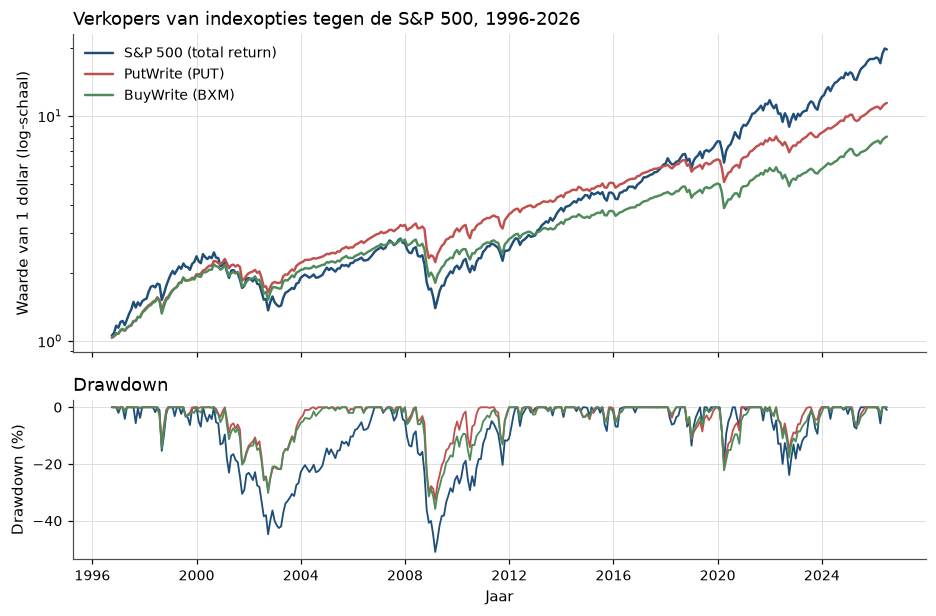

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True, height_ratios=[2, 1])
for i, name in enumerate(cboe_excess):
    dd = hap.drawdowns(cboe[name])
    axes[0].plot(dd.index, dd["wealth"], color=hap.plotting.COLORS[i], label=name)
    axes[1].plot(dd.index, 100 * dd["drawdown"], color=hap.plotting.COLORS[i], lw=1.2)
axes[0].set_yscale("log")
axes[0].set_title("Verkopers van indexopties tegen de S&P 500, 1996-2026")
axes[0].set_ylabel("Waarde van 1 dollar (log-schaal)")
axes[0].legend()
axes[1].set_title("Drawdown")
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("Drawdown (%)")
plt.show()

:::{figure} #cel-opties-crashrisico-put-index
:label: fig-opties-crashrisico-put-index
:width: 95%

De PutWrite-index loopt tot 2020 gelijk op met de S&P 500 bij twee derde van de
volatiliteit, en valt in de crisismaanden van 2008 en 2020 bijna even diep. Na 2020 blijft
hij achter: wie verzekering verkoopt, doet niet mee met een sterk stijgende markt.
:::

Over 358 maanden had de S&P 500 een excess rendement van $9{,}0\%$ per jaar bij $15{,}4\%$
volatiliteit, een Sharpe-ratio van $0{,}58$. De PUT-index haalde $6{,}5\%$ bij $10{,}5\%$, een
Sharpe-ratio van $0{,}62$; BXM $0{,}50$. Het verschil van $0{,}04$ tussen PUT en de index
is een vijfde van één standaardfout ($0{,}20$): dertig jaar data kunnen de twee niet van elkaar
onderscheiden. De scheefheid van PUT is $-1{,}66$ en de exces-kurtosis $6{,}8$, tegen
$-0{,}55$ en $0{,}8$ voor de index. De maximale drawdown ([](#fig-opties-crashrisico-put-index)) was $-33\%$ tegen $-51\%$, bijna
geheel in november 2007 – februari 2009 ($-32\%$). In februari–maart 2020 verloor PUT
$19{,}8\%$, *meer* dan de S&P 500 met $19{,}6\%$, bij een bèta van $0{,}58$. Tegen de
index geregresseerd is de alfa van PUT $1{,}3\%$ per jaar met $t = 1{,}1$.

De drie verwachtingen zijn uitgekomen, zoals in de simulatie: een premie die nauwelijks
meetbaar is, een staart die dat wel is. Israelov en Nielsen ontleedden de
BuyWrite-strategie en vonden: "The short volatility exposure realized a Sharpe ratio of
nearly 1.0 but contributed only 10% of the risk" {cite}`IsraelovNielsen2015b`; de premie is
reëel, maar in een indexproduct verdund door aandelenrisico. De koper komt er niet beter
vanaf: beschermende puts zijn volgens Israelov "quite ineffective at reducing drawdowns
versus the simple alternative of statically reducing exposure to the underlying asset"
{cite}`Israelov2019`, en in rustige markten geldt: "Option prices may be low, but their
expected values tend to be even lower" {cite}`IsraelovNielsen2015a`.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Opties maakten van crashrisico een dagelijks gemeten prijs.
Sprongen verklaren de vorm van de smirk, de ordening van Coval en Shumway volgt uit een
dalende SDF, en de variance risk premium heeft het teken dat het leverage effect voorspelt. Santa-Clara en Yan haalden uit zeven jaar optieprijzen een equity premium van
tien procent waarvan bijna een derde crashpremie, in een steekproef waarin het
gerealiseerde excess rendement negatief was. Op echte data vonden we de linksscheve
risiconeutrale verdeling, de voorspelkracht van de premie over 1990–2007, en een
PutWrite-index die niet onderdoet voor de markt.

**Waar het breekt.** Twee meetbare feiten. De voorspelkracht van de variance risk premium
verdwijnt na 2007: over 1990–2026 is de $t$-waarde bij drie maanden $0{,}6$. En de
"good deal" van het verkopen van puts is in dertig jaar indexdata niet te meten: $0{,}62$
tegen $0{,}58$ met een standaardfout van $0{,}20$. In één op de vijf twintigjarige
steekproeven zit geen crash, en dan lijkt een Sharpe-ratio van een derde er een van twee. Wat de optiemarkt goed meet, is de *prijs* van crashrisico;
wat ze niet levert, is een bewijs dat die prijs te hoog is.

**Risico of vergissing?** De Chicago-lezing: crashes zijn de toestanden waarin een euro
het meest waard is, sprongrisico is niet te hedgen, en de premie is de beloning voor een
risico dat iemand moet dragen, en dat in crises duurder wordt, zoals Pan vond. De
Yale-lezing: Jackwerth vond een SDF die na 1987 ergens stijgt in de index en noemde
mispricing "the most likely cause", en Saretto en Santa-Clara lazen hun resultaten als
"large misspricings in option markets which cannot be arbitraged away" door
transactiekosten en marges — *limits of arbitrage* (de grenzen aan wat kapitaalbeperkte
arbitrageurs kunnen corrigeren) in hun zuiverste vorm. Scheiden vraagt de
SDF in crashtoestanden, en die zijn per definitie zeldzaam. De data van deze lecture kiezen
niet, en Santa-Clara zelf staat met één been in elk kamp: hij schatte de premie als
beloning voor risico en liet zien dat marges haar onbereikbaar maken.

**Wat er daarna kwam.** Hetzelfde patroon — vaak een beetje winnen, zelden veel verliezen —
bleek ook de valutamarkt te beheersen, waar de *carry trade* een premie verdient die in
crises in één keer verdampt: zie [](#05-30-wisselkoersen).

## Oefeningen

:::{exercise}
:label: ex-opties-crashrisico-1

**Sprongpremies uit een machtsfunctie-SDF.** Laat op een sprongmoment de SDF met factor
$J^{-\gamma}$ springen (de index is een claim op consumptie, zoals in het toy-voorbeeld),
met $\log J \sim \mathcal N(\mu_J, \delta_J^2)$ onder $\mathbb P$ en intensiteit $\lambda^{\mathbb P}$.

1. Toon aan dat onder $\mathbb Q$ de intensiteit $\lambda^{\mathbb Q} = \lambda^{\mathbb P}\,
   \E^{\mathbb P}[J^{-\gamma}] = \lambda^{\mathbb P}\exp(-\gamma\mu_J + \tfrac12\gamma^2\delta_J^2)$ is en
   dat $\log J$ onder $\mathbb Q$ normaal is met gemiddelde $\mu_J - \gamma\delta_J^2$ en dezelfde
   spreiding.
2. Welke $\gamma$ geeft bij de sprongverdeling van de simulatie de verhouding
   $\lambda^{\mathbb Q}/\lambda^{\mathbb P} = 0{,}165/0{,}078$? Wat is dan de gemiddelde sprong
   onder $\mathbb Q$?
:::

:::{solution} ex-opties-crashrisico-1
:class: dropdown

**(1)** Over een kort interval $\mathrm dt$ is de kans op een sprong met grootte in
$\mathrm dj$ gelijk aan $\lambda^{\mathbb P}\mathrm dt\, f(j)\,\mathrm dj$, met $f$ de lognormale dichtheid.
De risiconeutrale kans is die kans maal $m/\E[m]$, en $\E[m] = 1 + O(\mathrm dt)$; op een
sprongmoment is $m$ evenredig met $j^{-\gamma}$ ten opzichte van geen sprong. Dus
$\lambda^{\mathbb Q} f^{\mathbb Q}(j) = \lambda^{\mathbb P} f(j)\, j^{-\gamma}$. Integreren over $j$ geeft
$\lambda^{\mathbb Q} = \lambda^{\mathbb P}\E[J^{-\gamma}]$, en met $x = \log j$ is
$f(j)j^{-\gamma} \propto \exp\bigl(-(x-\mu_J)^2/2\delta_J^2 - \gamma x\bigr)$; kwadraat afmaken geeft
een normale dichtheid met gemiddelde $\mu_J - \gamma\delta_J^2$ en vermenigvuldigingsfactor
$\exp(-\gamma\mu_J + \gamma^2\delta_J^2/2)$.

**(2)**

In [18]:
ratio = LAM_Q / LAM_P
gamma_jump = optimize.brentq(lambda g: -g * MU_J + 0.5 * g**2 * DELTA_J**2 - np.log(ratio), 0.0, 20.0)
mean_jump_q = np.exp(MU_J - gamma_jump * DELTA_J**2 + 0.5 * DELTA_J**2) - 1
print(f"lambda^Q / lambda^P = {ratio:.3f}  ->  gamma = {gamma_jump:.3f}")
print(f"gemiddelde sprong onder P: {KAPPA:.4f}, onder Q: {mean_jump_q:.4f}")

lambda^Q / lambda^P = 2.115  ->  gamma = 2.015
gemiddelde sprong onder P: -0.3000, onder Q: -0.3140


Een risicoaversie van ongeveer twee verdubbelt de intensiteit en maakt de gemiddelde crash
iets dieper ($-31{,}4\%$ tegen $-30\%$), dicht bij Santa-Clara en Yan, die met $\gamma = 2$
werken en $-31{,}6\%$ tegen $-29{,}5\%$ vinden. Een crashpremie van deze omvang vraagt geen
extreme risicoaversie, alleen grote crashes die met de consumptie samenvallen: de logica
van Rietz en Barro uit [](#05-27-drie-antwoorden).
:::

:::{exercise}
:label: ex-opties-crashrisico-2

**Modelvrije scheefheid.** Bereken voor de twee SPY-expiraties uit de replicatie
$\E^{\mathbb Q}[R]$, $\E^{\mathbb Q}[R^2]$ en $\E^{\mathbb Q}[R^3]$ met
[](#prop-opties-crashrisico-momenten), rechtstreeks uit de out-of-the-money-midkoersen
(trapeziumregel over de genoteerde uitoefenprijzen, zonder fit). Vergelijk de volatiliteit
en scheefheid met die van de Breeden-Litzenberger-dichtheid. Welke van de twee geeft de
extreemste getallen, en waarom?
:::

:::{solution} ex-opties-crashrisico-2
:class: dropdown

In [19]:
bkm_rows = {}
for label, sm in smiles.items():
    otm, T, F = sm["otm"], sm["T"], sm["F"]
    K, Q_price = otm["strike"].to_numpy(), otm["mid"].to_numpy()
    x, growth_T = np.log(K / F), np.exp(r_cc * T)
    mean_r = -growth_T * np.trapezoid(Q_price / K**2, K)
    second = growth_T * np.trapezoid(2 * (1 - x) * Q_price / K**2, K)
    third = growth_T * np.trapezoid((6 * x - 3 * x**2) * Q_price / K**2, K)
    var = second - mean_r**2
    bkm_rows[label] = {"vol modelvrij": np.sqrt(var / T),
                       "scheefheid modelvrij": (third - 3 * mean_r * second + 2 * mean_r**3) / var**1.5,
                       "vol BL-dichtheid": moments(*densities[label][:2])["sd"] / np.sqrt(T),
                       "scheefheid BL-dichtheid": moments(*densities[label][:2])["scheefheid"]}
pd.DataFrame(bkm_rows).T.round(4)

,vol modelvrij,scheefheid modelvrij,vol BL-dichtheid,scheefheid BL-dichtheid
1 maand,0.1481,-2.1386,0.1233,-1.2287
3 maanden,0.1810,-2.2638,0.1436,-1.2955


Hetzelfde teken, maar de modelvrije getallen zijn veel extremer: een volatiliteit van
$14{,}8\%$ en $18{,}1\%$ tegen $12{,}3\%$ en $14{,}4\%$, een scheefheid van $-2{,}14$ en
$-2{,}26$ tegen $-1{,}23$ en $-1{,}30$. Het verschil zit voorbij de laagste genoteerde put: de
dichtheid houdt daar op en wordt genormeerd, maar in [](#eq-opties-crashrisico-spanning)
bevat de prijs van die laatste put nog de waarde van alle toestanden daaronder. Afkappen onderschat dus vooral het derde moment;
tegelijk hebben juist de randquotes de breedste bied-laatmarges, zodat midkoersen de staart
kunnen overschatten. De oefening leert dat de linkerstaart ook in optieprijzen het slechtst
gemeten deel van de verdeling is.
:::

:::{exercise}
:label: ex-opties-crashrisico-3

**De straddle van Coval en Shumway.** Koop in het gekalibreerde model een
at-the-money-straddle op één maand tegen de $\mathbb Q$-prijs, houd hem één week (vijf
handelsdagen) aan onder $\mathbb P$, en waardeer hem dan opnieuw met
[](#eq-opties-crashrisico-merton). Bereken met een miljoen paden het verwachte
weekrendement, met standaardfout. Herhaal met $\lambda^{\mathbb P} = \lambda^{\mathbb Q}$ (geen
sprongpremie). Vergelijk met de "approximately three percent per week" van Coval en
Shumway.
:::

:::{solution} ex-opties-crashrisico-3
:class: dropdown

In [20]:
def straddle_week(lam_p, n_paths=1_000_000, S0=100.0, tau=21 / 252, days=5):
    """Mean and s.e. of the one-week return on an ATM straddle bought at the Q price."""
    price0 = sum(merton_price(S0, S0, tau, R_SIM, SIGMA_SIM, LAM_Q, MU_J, DELTA_J, kind)
                 for kind in ("call", "put"))
    dt_w = days / 252
    n = rng.poisson(lam_p * dt_w, n_paths)
    drift = R_SIM + ETA_SIGMA + (lam_p - LAM_Q) * KAPPA - lam_p * KAPPA - 0.5 * SIGMA_SIM**2
    S1 = S0 * np.exp(drift * dt_w + SIGMA_SIM * np.sqrt(dt_w) * rng.standard_normal(n_paths)
                     + n * MU_J + np.sqrt(n) * DELTA_J * rng.standard_normal(n_paths))
    price1 = sum(merton_price(S1, S0, tau - dt_w, R_SIM, SIGMA_SIM, LAM_Q, MU_J, DELTA_J, kind, n_max=8)
                 for kind in ("call", "put"))
    ret = price1 / price0 - 1
    return ret.mean(), ret.std(ddof=1) / np.sqrt(n_paths)


pd.DataFrame(
    {label: dict(zip(["gem. weekrendement", "SE"], straddle_week(lam)))
     for label, lam in (("met sprongpremie (lambda^P = 0,078)", LAM_P), ("zonder (lambda^P = lambda^Q)", LAM_Q))}
).T.round(4)

,gem. weekrendement,SE
"met sprongpremie (lambda^P = 0,078)",-0.0086,0.0003
zonder (lambda^P = lambda^Q),0.0032,0.0004


Met de sprongpremie verliest de straddle $0{,}86\%$ per week (standaardfout $0{,}03$), zonder
wint hij $0{,}32\%$: een at-the-money-straddle is niet delta-neutraal (elasticiteit ongeveer
$3{,}3$) en verdient de rente plus ruim drie keer de diffusiepremie. Coval en Shumway kijken
naar straddles met bèta nul, dus de vergelijkbare grootheid is het verschil, ongeveer
$-1{,}2$ procentpunt per week: minder dan hun drie procent. Onze kalibratie prijst alleen
crashes te hoog; drie procent per week vraagt opties die ook buiten crashes duur zijn, een
premie op gewone volatiliteit.
:::